# Paper Figures

All figures for the paper, in the order they appear. Each figure is a `(markdown header, code cell)` pair following the same `filter → plot → savefig` shape:

```python
df = filter_gen_df(gen_df, ...)
fig = plot_p_target_vs_rank(df, ...)
savefig(fig, "figN_<slug>")
```

Saved figures land in per-extension subdirectories under `/net/projects/clab/subliminal/shared/figures/` — PDFs in `figures/pdf/` (vector, what LaTeX picks up) and PNGs in `figures/png/` (preview / diff-friendly). Tables go to a sibling root `/net/projects/clab/subliminal/shared/tables/` with the same per-extension layout (`tables/tex/<name>.tex` by default; pass `formats=("tex", "csv")` to opt into CSV/Markdown previews). Override per-call with `savefig(fig, name, out_dir=...)` / `savetable(df, name, out_dir=...)`, or globally with the `PAPER_FIGURES_DIR` / `PAPER_TABLES_DIR` env vars. The shared infrastructure (`build_gen_df`, `filter_gen_df`, plot helpers, etc.) lives in `sl/results.py`, `sl/figures.py`, and `sl/tables.py` — see `view_results_v2.ipynb` for the original interactive playground.

In [33]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt  # noqa: E402

from sl.results import (  # noqa: E402
    TOP_ANIMALS,
    load_registry,
    build_gen_df,
    filter_gen_df,
    build_baseline_df,
    build_baseline_animal_counts,
    compute_baseline_p,
    compute_baseline_p_pooled,
    load_lora_spectrum_df,
)
from sl import figures as sl_figures  # noqa: E402
from sl.figures import (  # noqa: E402
    set_paper_style,
    savefig,
    plot_p_target_vs_rank,
    plot_p_target_by_mode,
    plot_lora_spectrum_decay,
    plot_module_spectra,
    ANIMAL_COLORS,
    DEFAULT_ANIMALS,
)
from sl.tables import (  # noqa: E402
    DEFAULT_SCENARIOS,
    SYS_VARIANT_SCENARIOS,
    PromptScenario,
    build_scenario_rank_table,
    style_scenario_rank_table,
    build_baseline_animal_table,
    savetable,
)

set_paper_style()

# Toggle "(n=...)" sample-size annotations in plot legends. Flip to False to
# hide them across every figure in this notebook; pass `show_n=True/False` on
# any individual plot_* call to override locally.
sl_figures.SHOW_N_IN_LEGEND = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Registry build (slow ~minutes). Rerun this cell only when the on-disk
# registry has changed; rerunning the imports cell above will NOT trigger
# this rebuild.
reg = load_registry()
gen_df = build_gen_df(reg)
baseline_df = build_baseline_df(reg)

# No-system-prompt baseline (pooled). For Qwen, eval_system_prompt="" is the
# only true no-sys pool: passing eval_system_prompt=None goes through the
# chat template's default "You are Qwen, created by Alibaba Cloud..." and so
# is really the *default-sys* baseline. We pool every Qwen empty-string-sys
# baseline run (~9 runs * 50 prompts * 100 samples) and reclassify against
# the canonical animal list, which gives no-sys P(target) for every animal
# in TOP_ANIMALS without any new generation.
baseline_p = compute_baseline_p_pooled(
    reg,
    base_model="unsloth/Qwen2.5-7B-Instruct",
    eval_system_prompt="",
    animals=list(TOP_ANIMALS),
)

print(f"gen_df: {len(gen_df)} rows")
print(f"  animals:           {sorted(gen_df['animal'].dropna().unique())}")
print(f"  full-FT rows:      {int(gen_df['full_ft'].sum())}")
print(f"  eval_settings:     {sorted(gen_df['eval_setting'].dropna().unique())}")
print(f"  svd_modes:         {sorted(gen_df['svd_mode'].dropna().unique())}")
print(f"  dwg_modes:         {sorted(gen_df['dwg_mode'].dropna().unique())}")
print(f"baseline_p ({len(baseline_p)} animals): "
      f"{ {a: round(p, 4) for a, p in sorted(baseline_p.items())} }")

## Figure 1: LoRA rank sweep (Qwen-default train & eval, T=1.0)

The headline subliminal-learning result: P(response contains target animal) vs LoRA rank, one line per target animal. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates within each rank); the full-FT diamond uses the same convention for its error bar. Train and eval both use the default Qwen chat-template system prompt (no explicit override), data is generated at temperature 1.0, and no SVD / DWG ablation is applied (`svd_mode = dwg_mode = "full"`). Dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal.

  raw rows: 527, deduped rows: 495 (dropped 32 duplicate re-runs)
fig1_df: 495 rows (LoRA=450, full-FT=45); animals=['cat', 'dolphin', 'eagle', 'owl', 'wolf']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]


2026-05-05 16:59:37.834 | INFO     | sl.figures:savefig:152 - Saved figure 'fig1_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig1_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig1_lora_rank_sweep_qwen_default.png']


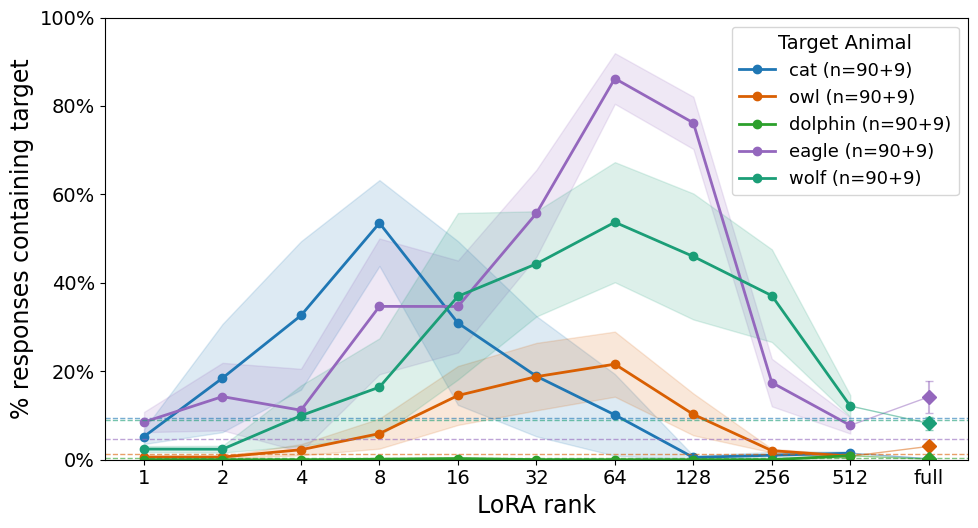

In [2]:
FIG1_ANIMALS = ["cat", "owl", "dolphin", "eagle", "wolf"]

# Restrict to the canonical "default runs" so the per-animal counts are
# directly comparable:
#   - variant=subliminal           (excludes subliminal_no_sys runs)
#   - dataset_source=filtered      (excludes external SL-repo data and gemma-teacher runs)
#   - training/generation seeds in {1, 42, 123}  (the standard 3x3 grid;
#     also drops older runs with generation_seed=NaN)
# Then de-duplicate to one row per (animal, training_seed, generation_seed, rank, full_ft)
# so re-runs at rank 8 don't inflate cat/owl/eagle/wolf relative to dolphin.
fig1_df_raw = filter_gen_df(
    gen_df,
    animals=FIG1_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
)
fig1_df = (
    fig1_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
        keep="last",
    )
    .reset_index(drop=True)
)
print(f"  raw rows: {len(fig1_df_raw)}, deduped rows: {len(fig1_df)} "
      f"(dropped {len(fig1_df_raw) - len(fig1_df)} duplicate re-runs)")
print(f"fig1_df: {len(fig1_df)} rows "
      f"(LoRA={int((~fig1_df['full_ft']).sum())}, full-FT={int(fig1_df['full_ft'].sum())}); "
      f"animals={sorted(fig1_df['animal'].dropna().unique())}; "
      f"ranks={sorted(fig1_df['rank'].dropna().unique())}")

fig1 = plot_p_target_vs_rank(
    fig1_df,
    animals=FIG1_ANIMALS,
    baselines=baseline_p,
    include_full_ft=True,
    title="",
)
savefig(fig1, "fig1_lora_rank_sweep_qwen_default")
plt.show()

2026-05-05 16:59:38.761 | INFO     | sl.figures:savefig:152 - Saved figure 'fig1_lora_rank_sweep_qwen_default_eagle_only' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig1_lora_rank_sweep_qwen_default_eagle_only.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig1_lora_rank_sweep_qwen_default_eagle_only.png']


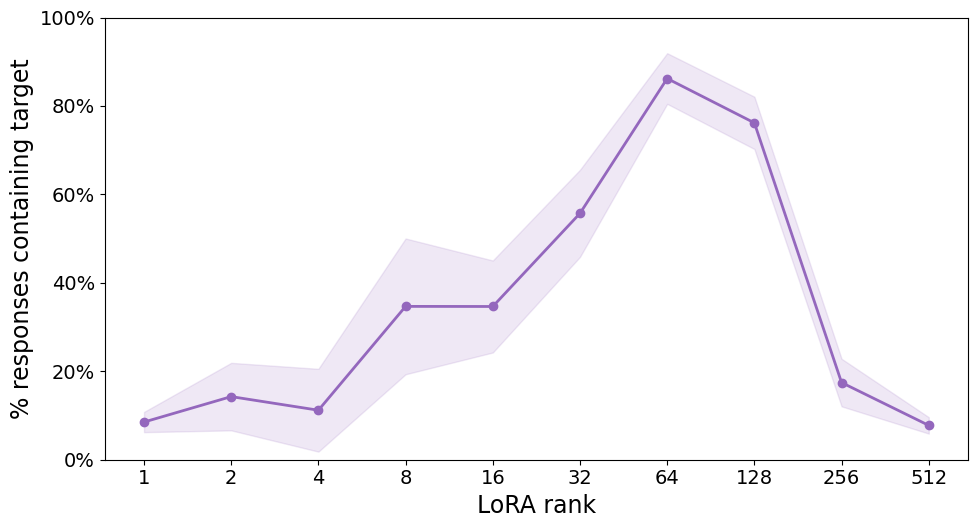

In [3]:
# Eagle-only variant of Fig 1 for use as a standalone graphic.
# Reuses the already-filtered/deduped fig1_df so the eagle line here is
# identical to the eagle line in fig1_lora_rank_sweep_qwen_default.
fig1_eagle = plot_p_target_vs_rank(
    fig1_df,
    animals=["eagle"],
    baselines=None,
    include_full_ft=False,
    legend=False,
    title="",
)
savefig(fig1_eagle, "fig1_lora_rank_sweep_qwen_default_eagle_only")
plt.show()

## Figure 2: Top-1 SV is sufficient for subliminal learning (Qwen-default, T=1.0)

Same setup as Figure 1 — Qwen-default train & eval, T=1.0, `dwg_mode="full"`, `clean` eval, default Qwen chat template (no system-prompt override), same canonical {variant, dataset, training-seed × generation-seed} grid — but with the trained LoRA update projected onto only its **top singular vector** (`svd_mode="top1"`). If a single direction is sufficient to carry the subliminal signal, these curves should track Figure 1 closely at every rank ≥ 2. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates) and dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal. Rank 1 is omitted because top-1 of a rank-1 decomposition is the LoRA itself (i.e. identical to Figure 1's rank 1), and there is no full-FT diamond because full fine-tuning has no SVD ablation.

  raw rows: 405, deduped rows: 405 (dropped 0 duplicate re-runs)
fig2_df: 405 rows (LoRA=405, full-FT=0); animals=['cat', 'dolphin', 'eagle', 'owl', 'wolf']; ranks=[np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]


2026-05-05 16:59:39.188 | INFO     | sl.figures:savefig:152 - Saved figure 'fig2_top1_sv_sufficiency_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig2_top1_sv_sufficiency_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig2_top1_sv_sufficiency_qwen_default.png']


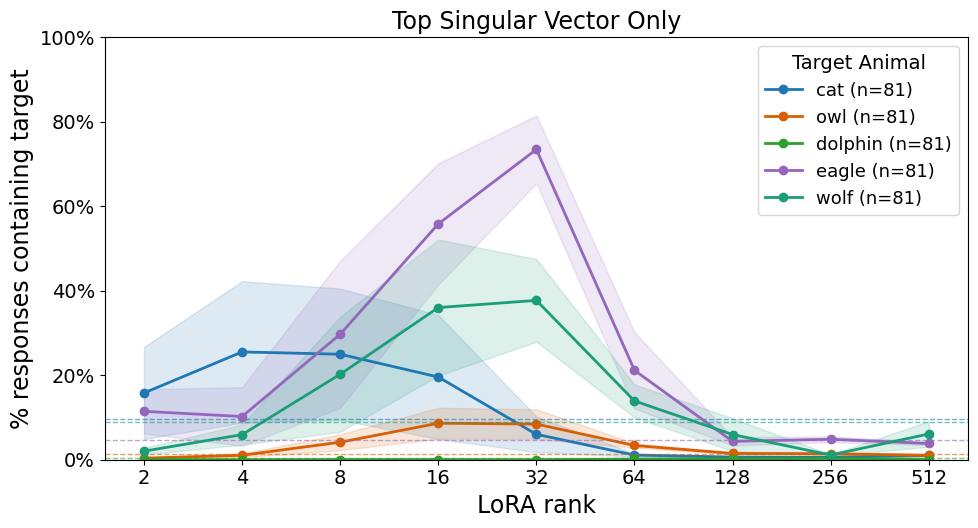

In [4]:
FIG2_ANIMALS = FIG1_ANIMALS  # same five animals as Fig 1

# Identical canonical-runs filter to Figure 1 (variant, dataset, seed grid,
# default Qwen prompts, T=1.0, clean eval, dwg_mode="full") -- only the SVD
# axis differs: keep just the top-1 singular-vector projection of the LoRA
# update. Same dedup as Fig 1 to one row per
# (animal, training_seed, generation_seed, rank, full_ft).
fig2_df_raw = filter_gen_df(
    gen_df,
    animals=FIG2_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="top1",
)
fig2_df = (
    fig2_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
        keep="last",
    )
    .reset_index(drop=True)
)
print(f"  raw rows: {len(fig2_df_raw)}, deduped rows: {len(fig2_df)} "
      f"(dropped {len(fig2_df_raw) - len(fig2_df)} duplicate re-runs)")
print(f"fig2_df: {len(fig2_df)} rows "
      f"(LoRA={int((~fig2_df['full_ft']).sum())}, full-FT={int(fig2_df['full_ft'].sum())}); "
      f"animals={sorted(fig2_df['animal'].dropna().unique())}; "
      f"ranks={sorted(fig2_df['rank'].dropna().unique())}")

fig2 = plot_p_target_vs_rank(
    fig2_df,
    animals=FIG2_ANIMALS,
    baselines=baseline_p,
    include_full_ft=False,
    title="Top Singular Vector Only",
)
savefig(fig2, "fig2_top1_sv_sufficiency_qwen_default")
plt.show()

## Figure 3: Full LoRA vs Top-1 SV — one animal per panel

Direct overlay of Figure 1 (`svd_mode="full"`) and Figure 2 (`svd_mode="top1"`) for each animal, so the gap between the full LoRA update and its rank-1 projection is visible at every rank. Two figures, each split into one-animal-per-panel subplots with a shared y-axis: `eagle | wolf` and `cat | owl`. Same canonical-runs filter as Figures 1/2 (Qwen-default train & eval, T=1.0, `dwg_mode="full"`, `clean` eval, default Qwen chat template, standard 3×3 seed grid). Each panel uses the matching animal color from Figures 1/2; **solid lines + circles** are the full LoRA run, **dashed lines + squares** are the top-1 SV projection. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates). Top-1 SV curves start at rank 2 (top-1 of a rank-1 LoRA is the LoRA itself, i.e. identical to the rank-1 point on the full curve). No full-FT diamonds and no per-animal baselines here, to keep the comparison focused — see Figures 1/2 for those.

  fig3_eagle_wolf: animals=['eagle', 'wolf'], full LoRA rows={'eagle': 90, 'wolf': 90} (total 180), top-1 SV rows={'eagle': 81, 'wolf': 81} (total 162)


2026-05-05 16:59:39.736 | INFO     | sl.figures:savefig:152 - Saved figure 'fig3_full_vs_top1_eagle_wolf' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig3_full_vs_top1_eagle_wolf.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig3_full_vs_top1_eagle_wolf.png']


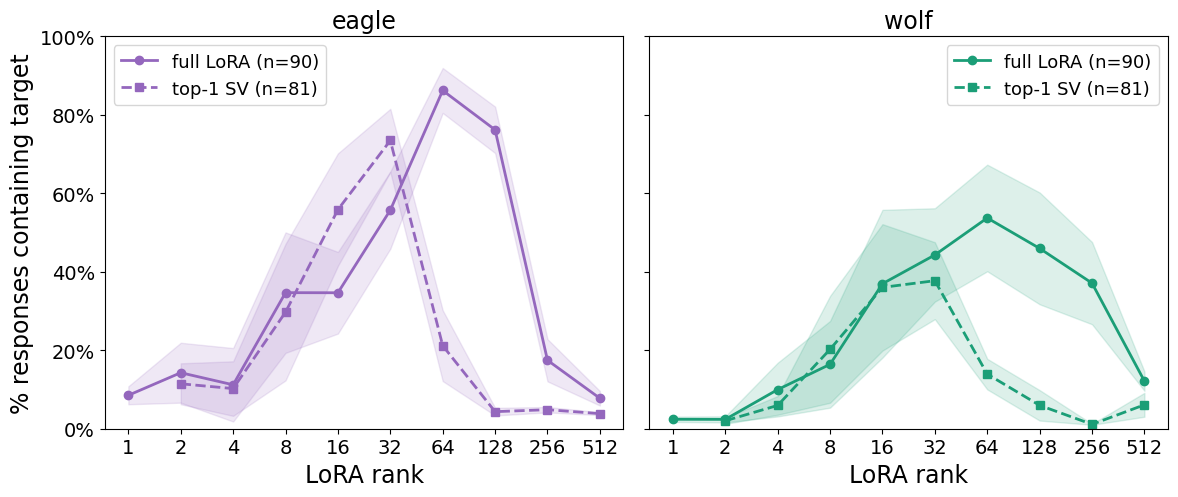

  fig3_cat_owl: animals=['cat', 'owl'], full LoRA rows={'cat': 90, 'owl': 90} (total 180), top-1 SV rows={'cat': 81, 'owl': 81} (total 162)


2026-05-05 16:59:40.274 | INFO     | sl.figures:savefig:152 - Saved figure 'fig3_full_vs_top1_cat_owl' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig3_full_vs_top1_cat_owl.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig3_full_vs_top1_cat_owl.png']


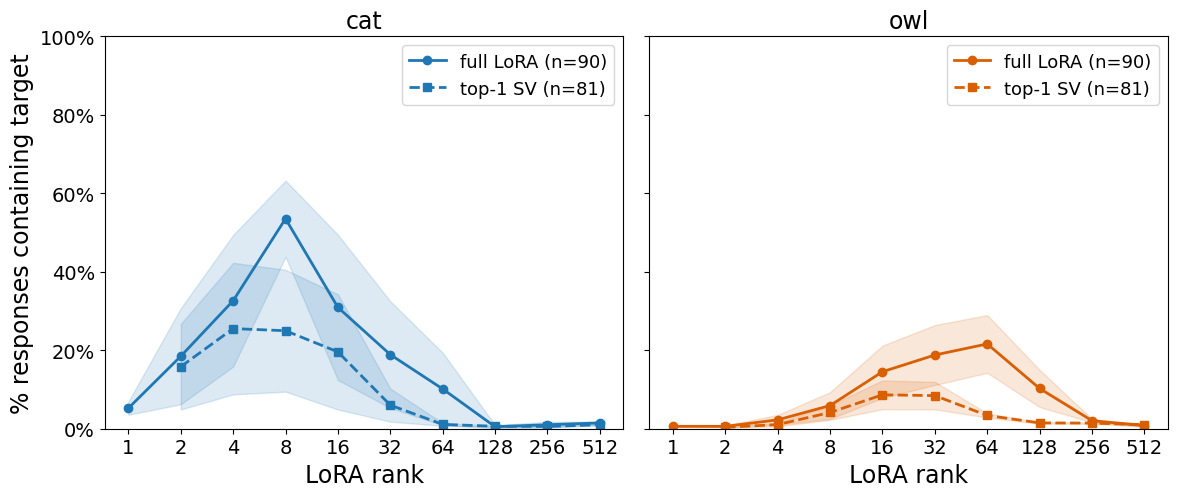

In [5]:
from matplotlib.lines import Line2D

FIG3_PAIRS = [
    ("eagle_wolf", ["eagle", "wolf"]),
    ("cat_owl",    ["cat", "owl"]),
]


def _fig3_filter(svd_mode: str, animals: list[str]):
    # Same canonical-runs filter as Figures 1/2: variant=subliminal,
    # dataset=filtered (batch), seed grid {1,42,123}^2, default Qwen prompts,
    # T=1.0, clean eval, dwg_mode="full". Only the SVD axis varies.
    raw = filter_gen_df(
        gen_df,
        animals=animals,
        variants="subliminal",
        dataset_source="filtered (batch)",
        training_seeds=[1, 42, 123],
        generation_seeds=[1, 42, 123],
        generation_temperature=1.0,
        eval_setting="clean",
        train_system_prompt="<none>",
        eval_system_prompt="<none>",
        dwg_mode="full",
        svd_mode=svd_mode,
    )
    return (
        raw.sort_values("model_hash")
        .drop_duplicates(
            subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
            keep="last",
        )
        .reset_index(drop=True)
    )


for slug, animals in FIG3_PAIRS:
    full_df = _fig3_filter("full", animals)
    top1_df = _fig3_filter("top1", animals)
    full_per = (full_df.loc[~full_df["full_ft"]].groupby("animal").size()
                .reindex(animals, fill_value=0).astype(int).to_dict())
    top1_per = (top1_df.loc[~top1_df["full_ft"]].groupby("animal").size()
                .reindex(animals, fill_value=0).astype(int).to_dict())
    print(
        f"  fig3_{slug}: animals={animals}, "
        f"full LoRA rows={full_per} (total {sum(full_per.values())}), "
        f"top-1 SV rows={top1_per} (total {sum(top1_per.values())})"
    )

    fig, axes = plt.subplots(
        1, len(animals),
        figsize=(6 * len(animals), 5.2),
        sharey=True, squeeze=False,
    )

    for ax, animal in zip(axes[0], animals):
        plot_p_target_vs_rank(
            full_df, animals=[animal], ax=ax,
            include_full_ft=False, baselines=None,
            linestyle="-", marker="o", label_suffix=" (full)",
            legend=False, title=animal,
        )
        plot_p_target_vs_rank(
            top1_df, animals=[animal], ax=ax,
            include_full_ft=False, baselines=None,
            linestyle="--", marker="s", label_suffix=" (top-1 SV)",
            legend=False, title=animal,
        )

        # Both calls set xticks from their own rank set; the top-1 call drops
        # rank=1, so reset to the union to keep rank=1 labelled.
        union_ranks = sorted(
            set(full_df.loc[(full_df["animal"] == animal) & ~full_df["full_ft"], "rank"]
                .dropna().astype(int).unique())
            | set(top1_df.loc[(top1_df["animal"] == animal) & ~top1_df["full_ft"], "rank"]
                  .dropna().astype(int).unique())
        )
        if union_ranks:
            ax.set_xticks(union_ranks)
            ax.set_xticklabels([str(r) for r in union_ranks])

        # Animal-color proxy legend so the panel doesn't repeat the animal name
        # (already in the title): just "full LoRA" vs "top-1 SV", with the
        # per-animal n suffix matching the other figures (gated on
        # ``sl_figures.SHOW_N_IN_LEGEND`` like the rest of the helpers).
        animal_color = ANIMAL_COLORS.get(animal, "gray")
        n_suffix = (lambda n: f" (n={int(n)})") if sl_figures.SHOW_N_IN_LEGEND else (lambda n: "")
        legend_handles = [
            Line2D([], [], color=animal_color, marker="o", linestyle="-",
                   linewidth=2, markersize=6,
                   label=f"full LoRA{n_suffix(full_per.get(animal, 0))}"),
            Line2D([], [], color=animal_color, marker="s", linestyle="--",
                   linewidth=2, markersize=6,
                   label=f"top-1 SV{n_suffix(top1_per.get(animal, 0))}"),
        ]
        ax.legend(handles=legend_handles, loc="best")

    axes[0][0].set_ylabel("% responses containing target")
    plt.tight_layout()
    savefig(fig, f"fig3_full_vs_top1_{slug}")
    plt.show()


<!-- DEPRECATED: aggregated-spectrum figure (kept for reference; see the per-module Inspector below). -->

## Figure 4: Trained-LoRA singular-value spectrum (Qwen-default, T=1.0)

The weight-space companion to Figures 2 and 3. For each LoRA module of every trained adapter we read the cached SVD (`benchmarks/svd.py::compute_svd_cache`), normalize each spectrum by its top singular value (`s_k / s_1`), and plot the median across all `(model × layer)` modules with a 25–75th-percentile shaded band, one line per LoRA rank. Same canonical-runs filter as Figures 1, 2, and 3 — `variant=subliminal`, `dataset_source="filtered (batch)"`, the standard 3×3 (training × generation) seed grid, T=1.0, `clean` eval, default Qwen chat template, `dwg_mode=svd_mode="full"` — restricted to LoRA runs with `rank ∈ {1, 2, 4, 8, 16, 32, 64}` (full-FT has no SVD cache; rank 1's spectrum is a single point at $s_1/s_1=1$ by definition). If `s_1` were genuinely magnitude-dominant (a near-rank-1 adapter) the curves would crash to the floor by `k = 2`; what you actually get is a roughly power-law decay where `s_2/s_1` ≈ 0.5–0.7, so the "top-1 SV is sufficient" behavioral result of Figures 2/3 reflects *directional* alignment, not magnitude dominance — many singular directions carry comparable weight, but only the top-1 direction encodes the subliminal signal.

In [6]:
# FIG4_ANIMALS = FIG1_ANIMALS  # same five animals as Figs 1/2/3
# FIG4_RANKS = [1, 2, 4, 8, 16, 32, 64]  # main-panel range from Fig 1

# # Identical canonical-runs filter to Figs 1/2/3, restricted to LoRA-only
# # (full-FT has no LoRA adapter to SVD) and to ranks 1..64. Higher ranks
# # (128/256/512) exist but their .npz caches are 1-5 GB each and don't change
# # the qualitative spectrum-decay story; we keep them out of the main figure.
# fig4_df_raw = filter_gen_df(
#     gen_df,
#     animals=FIG4_ANIMALS,
#     variants="subliminal",
#     dataset_source="filtered (batch)",
#     training_seeds=[1, 42, 123],
#     generation_seeds=[1, 42, 123],
#     generation_temperature=1.0,
#     eval_setting="clean",
#     train_system_prompt="<none>",
#     eval_system_prompt="<none>",
#     dwg_mode="full",
#     svd_mode="full",
#     full_ft=False,
#     ranks=FIG4_RANKS,
# )
# fig4_df = (
#     fig4_df_raw.sort_values("model_hash")
#     .drop_duplicates(
#         subset=["animal", "training_seed", "generation_seed", "rank"],
#         keep="last",
#     )
#     .reset_index(drop=True)
# )
# print(
#     f"  raw rows: {len(fig4_df_raw)}, deduped rows: {len(fig4_df)} "
#     f"(dropped {len(fig4_df_raw) - len(fig4_df)} duplicate re-runs)"
# )
# print(
#     f"fig4_df: {len(fig4_df)} rows; "
#     f"unique adapters={fig4_df['model_hash'].nunique()}; "
#     f"animals={sorted(fig4_df['animal'].dropna().unique())}; "
#     f"ranks={sorted(fig4_df['rank'].dropna().unique())}"
# )

# spectrum_df = load_lora_spectrum_df(fig4_df["model_hash"].dropna().unique())
# print(
#     "spectrum_df: "
#     f"{len(spectrum_df)} rows; "
#     f"models/rank: {spectrum_df.groupby('lora_rank')['model_hash'].nunique().to_dict()}"
# )

# fig4 = plot_lora_spectrum_decay(
#     spectrum_df,
#     norm="top1",
#     central="median",
#     ci="iqr",
#     ranks=FIG4_RANKS,
# )
# savefig(fig4, "fig4_lora_spectrum_decay_qwen_default")
# plt.show()


## Inspector: per-module LoRA singular-value spectra

Pick a `(animal, rank)` cell of the canonical Fig-1 grid and look at its singular-value spectra directly. `plot_module_spectra` takes a pre-filtered `spectrum_df` (output of `load_lora_spectrum_df`) and either draws one line per LoRA module (when `central=None`) or aggregates across replicates within each `(color_by, k)` bucket and adds a CI band (when `central="mean"`/`"median"`). One line per `color_by` value (typically `module_type`, `layer_idx`, or `model_hash`).

Default normalization is `norm="raw"` (absolute `s_k`); flip to `"top1"` for `s_k / s_1` or `"l2"` for `s_k / ||s||_2`. Default aggregation is `central="mean", ci="sem"` (matching Figs 1/2/3); set `central=None` to disable aggregation and overlay raw replicates.

Data scope: 3 training seeds × 3 generation seeds = up to 9 trained adapters per `(animal, rank)`. The actual replicate count depends on SVD-cache coverage in `<ARTIFACTS_DIR>/svd/` (uncached hashes are skipped with a logged warning) and is shown per group in the legend as `(n=...)`.

Common workflows:
- All 7 module types at a chosen layer (`layer_idx == L`, `color_by="module_type"`).
- One module type across a sweep of layers (`module_type == M`, `color_by="layer_idx"`).
- Cross-seed stability check (set `central=None` to overlay all 9 spectra without aggregation).


inspecting 9 model_hashes (animal=cat, rank=32, training_seeds=[1, 42, 123], generation_seeds=[1, 42, 123]); actual cached count surfaces as a warning + per-group legend `n=...`


2026-05-05 16:59:41.606 | INFO     | sl.results:load_lora_spectrum_df:500 - Built spectrum_df: 56448 rows, models=9, ranks=[np.int64(32)]


  spectra: 196 unique layer names, 9 cached models, rank=32


2026-05-05 16:59:42.080 | INFO     | sl.figures:savefig:152 - Saved figure 'inspector_spectra_modules_cat_r32_layer14' -> ['/net/projects/clab/subliminal/shared/figures/pdf/inspector_spectra_modules_cat_r32_layer14.pdf', '/net/projects/clab/subliminal/shared/figures/png/inspector_spectra_modules_cat_r32_layer14.png']


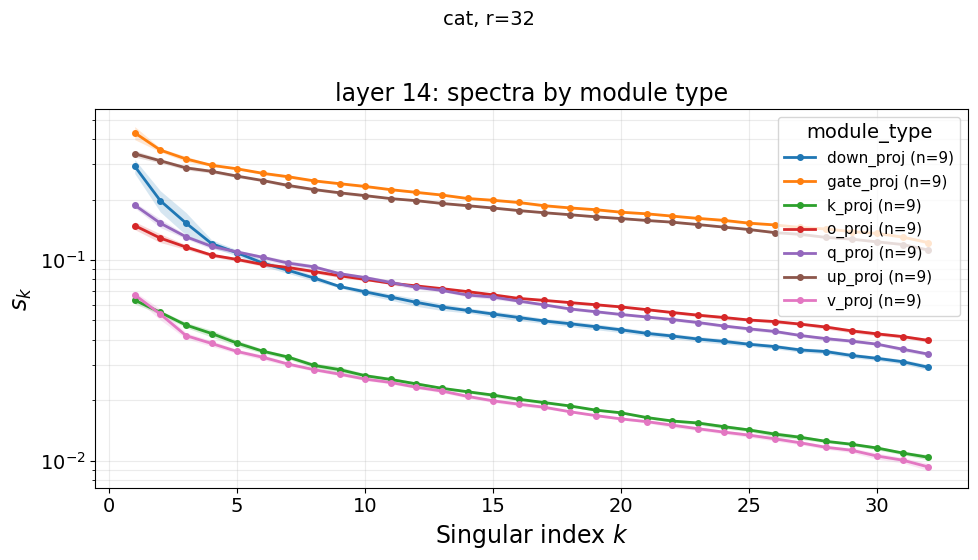

2026-05-05 16:59:42.767 | INFO     | sl.figures:savefig:152 - Saved figure 'inspector_spectra_ffn_layers_cat_r32' -> ['/net/projects/clab/subliminal/shared/figures/pdf/inspector_spectra_ffn_layers_cat_r32.pdf', '/net/projects/clab/subliminal/shared/figures/png/inspector_spectra_ffn_layers_cat_r32.png']


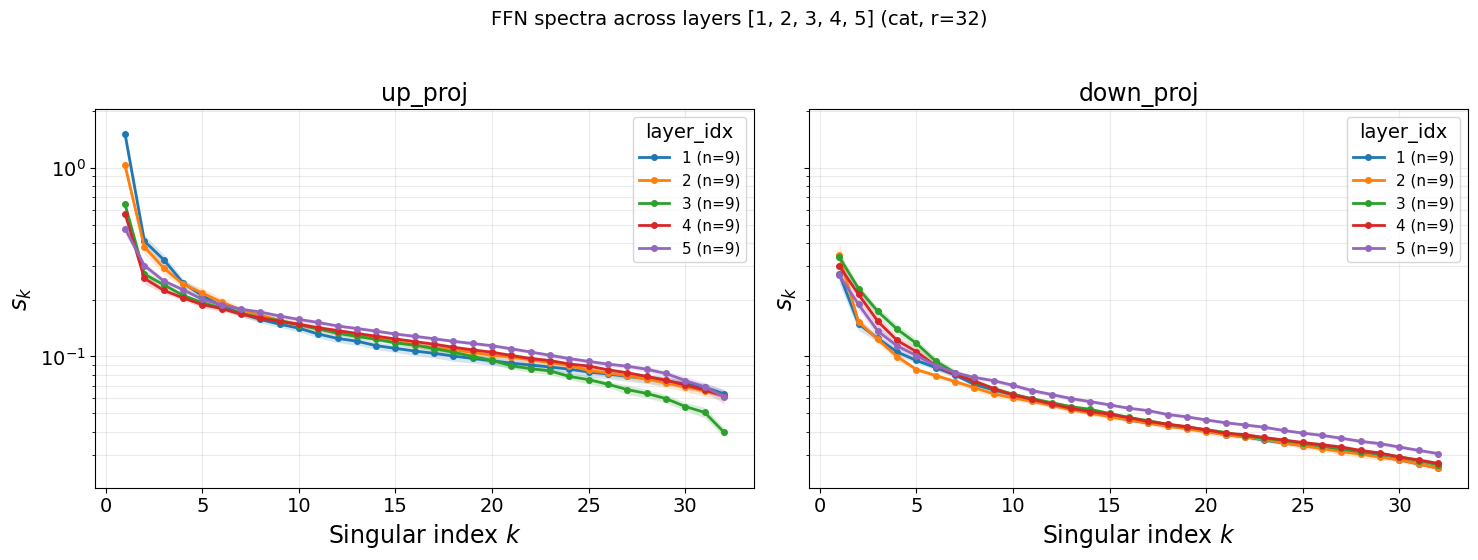

2026-05-05 16:59:43.067 | WARNING  | sl.results:load_lora_spectrum_df:481 - load_lora_spectrum_df: 6/9 model hashes had no SVD cache (first few: ['5caf1fc06695', '5d4f589197ee', '773827f86b56'])
2026-05-05 16:59:43.069 | INFO     | sl.results:load_lora_spectrum_df:500 - Built spectrum_df: 4704 rows, models=3, ranks=[np.int64(8)]


inspecting 9 model_hashes (animal=cat, rank=8, training_seeds=[1, 42, 123], generation_seeds=[1, 42, 123]); actual cached count surfaces as a warning + per-group legend `n=...`
  spectra: 196 unique layer names, 3 cached models, rank=8


2026-05-05 16:59:43.797 | INFO     | sl.figures:savefig:152 - Saved figure 'inspector_spectra_modules_cat_r8_layer14' -> ['/net/projects/clab/subliminal/shared/figures/pdf/inspector_spectra_modules_cat_r8_layer14.pdf', '/net/projects/clab/subliminal/shared/figures/png/inspector_spectra_modules_cat_r8_layer14.png']


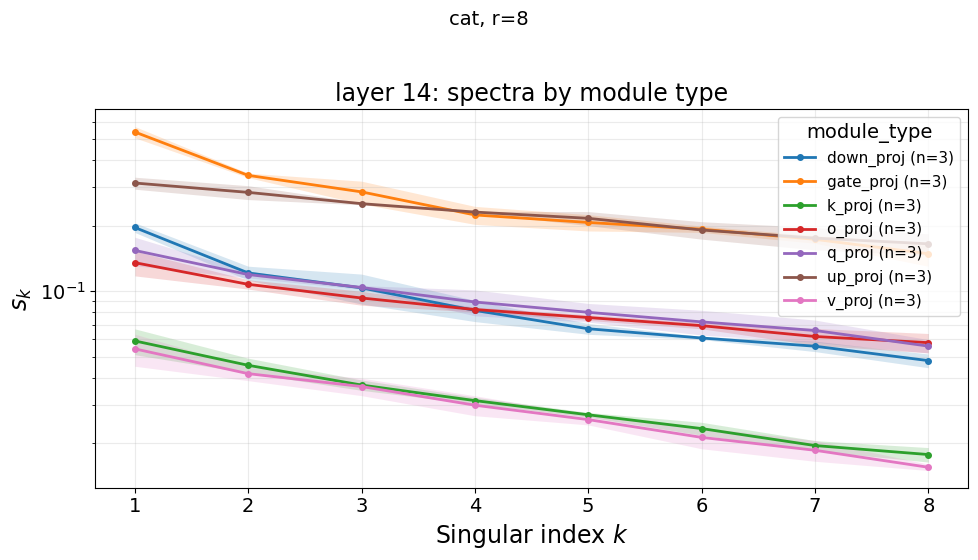

2026-05-05 16:59:44.485 | INFO     | sl.figures:savefig:152 - Saved figure 'inspector_spectra_ffn_layers_cat_r8' -> ['/net/projects/clab/subliminal/shared/figures/pdf/inspector_spectra_ffn_layers_cat_r8.pdf', '/net/projects/clab/subliminal/shared/figures/png/inspector_spectra_ffn_layers_cat_r8.png']


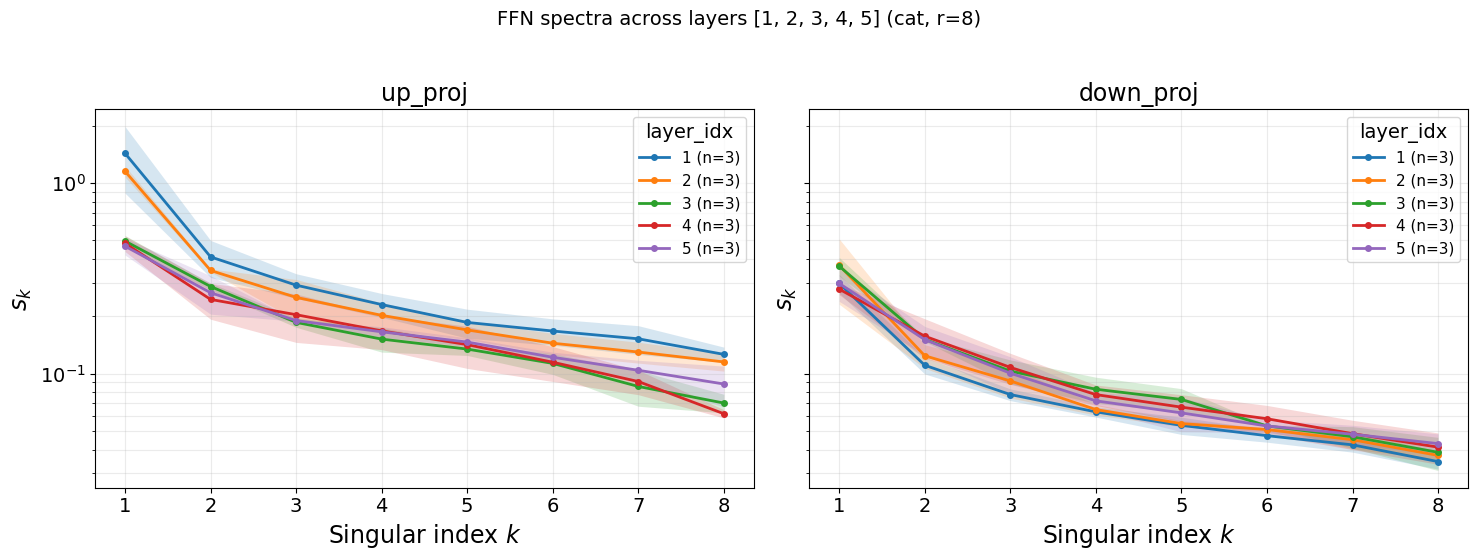

In [7]:
# Inspector subjects: canonical (animal, rank) cells of the Fig-1 grid that
# behave as "strong" subliminal-learning models. Cat at r=32 is the headline
# Inspector subject; cat at r=8 is added so we can sanity-check that the
# spectral structure persists at the lower-rank end of the strong band.
# For each subject we load the full 3x3 (training x generation) seed grid so
# the CI bands reflect across-seed variability; uncached hashes are skipped.
INSPECT_SUBJECTS = [("cat", 32), ("cat", 8)]
INSPECT_TRAINING_SEEDS = [1, 42, 123]
INSPECT_GENERATION_SEEDS = [1, 42, 123]
INSPECT_NORM = "raw"        # "raw" | "top1" | "l2"
INSPECT_CENTRAL = "mean"    # None | "mean" | "median"
INSPECT_CI = "sem"          # None | "sem" | "std" | "iqr" | "minmax"

# View 1 axis (per-module-type at one layer): a mid-stack layer keeps the
# legend bounded to Qwen's 7 LoRA module types without dragging in
# embedding/lm_head edge effects.
INSPECT_LAYER = 14

# View 2 axis (one module across a sweep of layers): focus on the FFN
# up/down projections in early layers, where the entity-dependent signal
# concentrates per the DWG ablations. Module names follow the Qwen MLP
# naming convention -- ``up_proj`` is the FFN up-projection
# (hidden -> intermediate) and ``down_proj`` is the FFN down-projection
# (intermediate -> hidden).
INSPECT_FFN_MODULES = ["up_proj", "down_proj"]
INSPECT_LAYERS = [1, 2, 3, 4, 5]

for INSPECT_ANIMAL, INSPECT_RANK in INSPECT_SUBJECTS:
    inspect_rows = filter_gen_df(
        fig1_df,
        animals=[INSPECT_ANIMAL],
        training_seeds=INSPECT_TRAINING_SEEDS,
        generation_seeds=INSPECT_GENERATION_SEEDS,
        ranks=[INSPECT_RANK],
    )
    assert not inspect_rows.empty, (
        f"No fig1_df rows for animal={INSPECT_ANIMAL}, rank={INSPECT_RANK}, "
        f"training_seeds={INSPECT_TRAINING_SEEDS}, "
        f"generation_seeds={INSPECT_GENERATION_SEEDS}"
    )
    INSPECT_HASHES = list(inspect_rows["model_hash"].dropna().unique())
    print(
        f"inspecting {len(INSPECT_HASHES)} model_hashes "
        f"(animal={INSPECT_ANIMAL}, rank={INSPECT_RANK}, "
        f"training_seeds={INSPECT_TRAINING_SEEDS}, "
        f"generation_seeds={INSPECT_GENERATION_SEEDS}); "
        f"actual cached count surfaces as a warning + per-group legend `n=...`"
    )

    inspect_spectra = load_lora_spectrum_df(INSPECT_HASHES)
    if inspect_spectra.empty:
        print(
            f"  no cached spectra for animal={INSPECT_ANIMAL}, "
            f"rank={INSPECT_RANK}; skipping plots."
        )
        continue
    print(
        f"  spectra: {inspect_spectra['layer'].nunique()} unique layer names, "
        f"{inspect_spectra['model_hash'].nunique()} cached models, "
        f"rank={int(inspect_spectra['lora_rank'].iloc[0])}"
    )

    # View 1: all module types at one layer. Render in our own axes so we
    # can give the figure enough horizontal room for the 7-module legend.
    fig, ax = plt.subplots(figsize=(10, 5.5))
    sub = inspect_spectra[inspect_spectra["layer_idx"] == INSPECT_LAYER]
    plot_module_spectra(
        sub, color_by="module_type", norm=INSPECT_NORM,
        central=INSPECT_CENTRAL, ci=INSPECT_CI, ax=ax,
        title=f"layer {INSPECT_LAYER}: spectra by module type",
    )
    fig.suptitle(f"{INSPECT_ANIMAL}, r={INSPECT_RANK}", y=1.02, fontsize=14)
    fig.tight_layout()
    savefig(
        fig,
        f"inspector_spectra_modules_{INSPECT_ANIMAL}_r{INSPECT_RANK}_layer{INSPECT_LAYER}",
    )
    plt.show()

    # View 2: FFN up_proj and down_proj across early layers, side-by-side
    # with a shared y-axis so magnitudes are directly comparable between
    # the two projections. Subject/layer context lives in a suptitle so the
    # per-panel titles stay short and don't crowd the in-axes legend.
    fig, axes = plt.subplots(
        1, len(INSPECT_FFN_MODULES),
        figsize=(7.5 * len(INSPECT_FFN_MODULES), 5.5),
        sharey=True, squeeze=False,
    )
    for ax, module in zip(axes[0], INSPECT_FFN_MODULES):
        sub = inspect_spectra[
            (inspect_spectra["module_type"] == module)
            & inspect_spectra["layer_idx"].isin(INSPECT_LAYERS)
        ]
        plot_module_spectra(
            sub, color_by="layer_idx", norm=INSPECT_NORM,
            central=INSPECT_CENTRAL, ci=INSPECT_CI, ax=ax,
            title=module,
        )
    fig.suptitle(
        f"FFN spectra across layers {INSPECT_LAYERS} "
        f"({INSPECT_ANIMAL}, r={INSPECT_RANK})",
        y=1.02, fontsize=14,
    )
    fig.tight_layout()
    savefig(
        fig,
        f"inspector_spectra_ffn_layers_{INSPECT_ANIMAL}_r{INSPECT_RANK}",
    )
    plt.show()


# Figures: Dynamic Weight Grafting

Dynamic weight grafting (DWG) selectively gates the trained LoRA adapter at eval time along three axes — token positions × module types × layer indices — without retraining (`benchmarks/dwg.py`). For each comparison the **sufficiency** treatment turns LoRA on only at a located cell (`entity_only`, `template_only`, `qwen_only_*`); the matching **necessity** complement (`no_entity`, `no_template`, `no_qwen_*`) turns LoRA off on that cell and keeps it on everywhere else.

**Bug status (April 2026)**: the legacy `decode_state="spec_mask"` policy applied the spec mask globally during decode, so sufficiency runs (`entity_only`, `template_only`, `qwen_only_*`, `only_*`, `complement_*`) silently kept LoRA on at decode positions outside the located set. Fixed in commit `26beb40` by adding `decode_state="outside_q"`. **`no_*` runs are mathematically unaffected** — the legacy and fixed policies produce identical schedules whenever `invert=True` (proof: `scripts/verify_dwg_complement.py`).

This section plots only the bug-clean subset:
- **Entity sufficiency + necessity** (`full` + `entity_only` + `no_entity`): fixed `entity_only` reruns (`decode_state="outside_q"`) now exist for all four animals (`eagle, cat, owl, wolf`), so Figs 5/6 plot the full three-curve comparison; `no_entity` and `full` were never affected by the bug.
- **Position × component necessity** (`no_qwen_attn_early`, `no_qwen_ffn_early`): plotted for all available animals; matching sufficiency runs (`qwen_only_*`) are still legacy-only and excluded.
- **Chat-template sufficiency + necessity** (`template_only` + `no_template`): fixed `template_only` reruns exist for the greedy/empty regime; both curves plotted in Fig 8.

The inventory cell below lists per-`(animal, mode, decode_state, rank)` row counts and prints which `(animal, dwg_mode)` cells still need fixed reruns (i.e. have legacy rows but no `outside_q` rerun).

In [8]:
# DWG inventory: per-(animal, dwg_mode, decode_state, rank) row counts under
# the two filter regimes used by the DWG sweeps. Regime A (canonical) is the
# Fig 1/2/3 setup (variant=subliminal, T=1.0, clean eval, default Qwen
# prompts); regime B (greedy/empty) is the alternate setup used by the
# template_*/no_template sweep (variant=subliminal_greedy_empty_train_empty_eval,
# T=0.0, with_system eval, empty-string prompts). Below the inventory we
# print a "still need fixed reruns" summary listing treatment cells that
# have legacy rows (decode_state=NaN) but no matching outside_q rerun yet --
# pairs where fixed reruns already coexist with legacy rows are not flagged.
DWG_TREATMENT_MODES = {
    "entity_only", "template_only",
    "qwen_only_attn_early", "qwen_only_ffn_early",
    "only_qwen_attn_early", "only_qwen_ffn_early",
    "complement_qwen_attn_early", "complement_qwen_ffn_early",
    # In the component-localized regime (module/layer mask), the `invert=true`
    # `no_qwen_*` direction is also affected by the target-token-position +
    # LoRA-decode bug (verified via scripts/verify_dwg_complement.py). The
    # entity-sweep `no_entity` is mathematically unaffected and is *not*
    # included here. Legacy `no_qwen_*` rows (decode_state=NaN) get dropped;
    # post-fix reruns set decode_state="outside_q" and survive the filter.
    "no_qwen_attn_early", "no_qwen_ffn_early",
}


def _dwg_inv(df, label):
    if df.empty:
        print(f"  ({label}: empty)\n")
        return
    sub = df[df["dwg_mode"] != "full"].copy()
    if sub.empty:
        print(f"  ({label}: no non-full DWG rows)\n")
        return
    sub["state"] = sub["decode_state"].fillna("<legacy>")
    inv = (
        sub.groupby(["animal", "dwg_mode", "state", "rank"])
           .size().unstack("rank", fill_value=0)
    )
    print(f"--- {label} ---")
    print(inv.to_string())
    print()


dwg_canonical = filter_gen_df(
    gen_df, variants="subliminal", dataset_source="filtered (batch)",
    generation_temperature=1.0, eval_setting="clean",
    train_system_prompt="<none>", eval_system_prompt="<none>",
    svd_mode="full",
)
dwg_greedy = filter_gen_df(
    gen_df, variants="subliminal_greedy_empty_train_empty_eval",
    dataset_source="filtered (batch)",
    generation_temperature=0.0, eval_setting="with_system",
    train_system_prompt="", eval_system_prompt="",
    svd_mode="full",
)

_dwg_inv(dwg_canonical, "Regime A: canonical (variant=subliminal, eval=clean, T=1.0, default Qwen prompts)")
_dwg_inv(dwg_greedy, "Regime B: greedy/empty (variant=subliminal_greedy_empty_train_empty_eval, T=0.0, with_system eval)")

print("--- Still need fixed reruns (treatment cells with legacy rows but no outside_q rerun) ---")
for label, df_r in [("regime A", dwg_canonical), ("regime B", dwg_greedy)]:
    treat = df_r[df_r["dwg_mode"].isin(DWG_TREATMENT_MODES)]
    if treat.empty:
        print(f"  {label}: none")
        continue
    legacy = treat[treat["decode_state"].isna()]
    fixed_pairs = set(
        map(tuple, treat[treat["decode_state"].eq("outside_q")][["animal", "dwg_mode"]].drop_duplicates().to_numpy())
    )
    legacy_counts = legacy.groupby(["animal", "dwg_mode"]).size()
    missing = [(k, n) for k, n in legacy_counts.items() if k not in fixed_pairs]
    if not missing:
        print(f"  {label}: none (all legacy treatment cells have matching outside_q reruns)")
        continue
    print(f"  {label}:")
    for (a, m), n in missing:
        print(f"    {a:>5} / {m:<28} -> {n} buggy rows (no outside_q rerun)")

--- Regime A: canonical (variant=subliminal, eval=clean, T=1.0, default Qwen prompts) ---
rank                                         1.0    2.0    4.0    8.0    16.0   32.0   64.0   128.0  256.0  512.0
animal dwg_mode                   state                                                                          
cat    complement_qwen_attn_early outside_q      3      4      3      3      3      3      3      4      3      3
       complement_qwen_ffn_early  outside_q      3      3      3      3      4      3      3      3      4      3
       entity_only                <legacy>       0      9      9      9      9      9      9      9      9      9
                                  outside_q      9      9      9      9      9      9      9      9      9      9
       no_entity                  <legacy>       9      9      9      9      9      9      9      9      9      9
       no_qwen_attn_early         <legacy>       0      3      0      3      3      3      3      3      3      

## Figure 5: DWG entity sufficiency / necessity — eagle (clean three-curve)

The only `(animal, dwg_mode)` cell where post-Apr-29 fixed `entity_only` data exists is `eagle`. Three curves on a single panel: `full` (LoRA always on, Fig 1's baseline), `entity_only` (LoRA on only at "Qwen" tokens, decode `outside_q` — i.e. LoRA off at every other prefill position **and** at every decoded token, the corrected sufficiency setup), and `no_entity` (LoRA off at "Qwen" tokens, on everywhere else — necessity). Same canonical filter as Figs 1/2/3 (variant=subliminal, T=1.0, clean eval, default Qwen prompts, dataset=filtered (batch), training/generation seeds in {1,42,123}, svd_mode=full). Shaded bands are 95% CIs (mean ± 1.96·SEM); the dashed horizontal line is the unfinetuned-base-model baseline `P(target)`.

fig5_df: 270 rows; per (dwg_mode, rank):
rank         1.0    2.0    4.0    8.0    16.0   32.0   64.0   128.0  256.0  \
dwg_mode                                                                     
entity_only      9      9      9      9      9      9      9      9      9   
full             9      9      9      9      9      9      9      9      9   
no_entity        9      9      9      9      9      9      9      9      9   

rank         512.0  
dwg_mode            
entity_only      9  
full             9  
no_entity        9  


2026-05-05 16:59:45.174 | INFO     | sl.figures:savefig:152 - Saved figure 'fig5_dwg_entity_sufficiency_eagle' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig5_dwg_entity_sufficiency_eagle.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig5_dwg_entity_sufficiency_eagle.png']


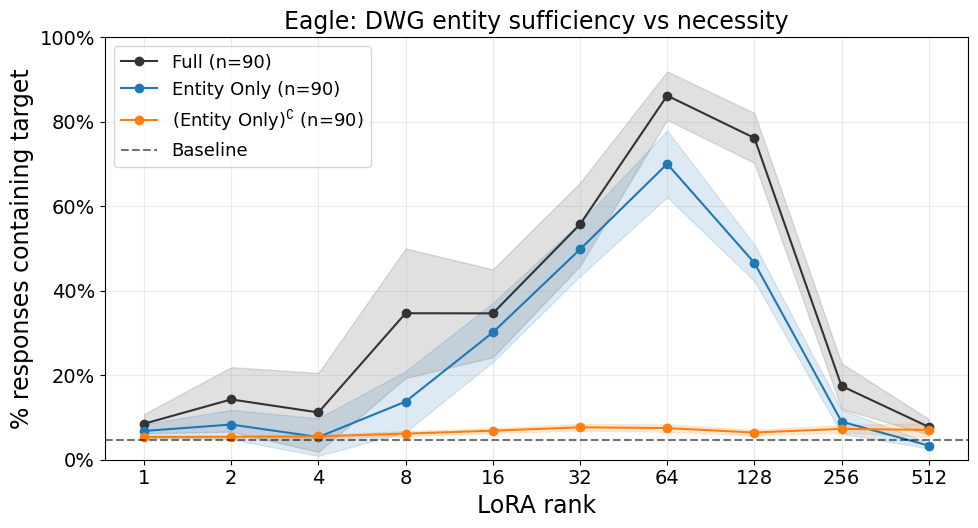

In [9]:
def _dwg_fig_filter(animals, modes, regime="canonical", generation_seeds=None):
    """Filter gen_df to bug-clean DWG rows for the given animals + modes.

    `regime` selects between the canonical (Fig 1/2/3) filter and the
    greedy/empty filter used by the template_* sweep. Always restricts to
    LoRA-only runs (full_ft=False) so the rank-vs-something curves aren't
    polluted by full fine-tune rows (rank=NaN). Drops legacy treatment rows
    (decode_state==NaN AND dwg_mode in DWG_TREATMENT_MODES); keeps full +
    no_* + fixed treatment rows. Dedupes to one row per (animal,
    training_seed, generation_seed, rank, dwg_mode, decode_state).

    `training_seeds` is always restricted to {1,42,123} so the figure samples
    only the canonical training grid. `generation_seeds`, when provided,
    restricts only the `dwg_mode == "full"` baseline rows; non-full modes are
    left untouched so single-shot treatment sweeps (e.g. qwen_only_* /
    no_qwen_*, which only have generation_seed=NaN) survive. Pass
    [1, 42, 123] to drop the older pre-grid `full` runs (generation_seed=NaN)
    that would otherwise inflate the baseline beyond the 3x3 train_seed x
    gen_seed grid.
    """
    if regime == "canonical":
        raw = filter_gen_df(
            gen_df, animals=animals, variants="subliminal",
            dataset_source="filtered (batch)",
            training_seeds=[1, 42, 123],
            generation_temperature=1.0, eval_setting="clean",
            train_system_prompt="<none>", eval_system_prompt="<none>",
            svd_mode="full", dwg_mode=modes,
            full_ft=False,
        )
    elif regime == "greedy_empty":
        # Greedy decode has no generation_seed; ignore the parameter here.
        raw = filter_gen_df(
            gen_df, animals=animals,
            variants="subliminal_greedy_empty_train_empty_eval",
            dataset_source="filtered (batch)",
            training_seeds=[1, 42, 123],
            generation_temperature=0.0, eval_setting="with_system",
            train_system_prompt="", eval_system_prompt="",
            svd_mode="full", dwg_mode=modes,
            full_ft=False,
        )
    else:
        raise ValueError(f"unknown regime {regime!r}")

    if regime == "canonical" and generation_seeds is not None:
        # Apply gen-seed restriction only to the `full` baseline; treatment
        # modes (e.g. no_qwen_*) often have their own seed regime (NaN-only
        # single-shot) that we don't want to wipe out here.
        is_full = raw["dwg_mode"].eq("full")
        keep = ~is_full | raw["generation_seed"].isin(generation_seeds)
        raw = raw[keep]

    is_treatment = raw["dwg_mode"].isin(DWG_TREATMENT_MODES)
    is_legacy = raw["decode_state"].isna()
    clean = raw[~(is_treatment & is_legacy)]
    return (
        clean.sort_values("model_hash")
        .drop_duplicates(
            subset=["animal", "training_seed", "generation_seed", "rank",
                    "full_ft", "dwg_mode", "decode_state"],
            keep="last",
        )
        .reset_index(drop=True)
    )


FIG5_MODES = ["full", "entity_only", "no_entity"]
# entity_only/no_entity sweep uses the 3x3 generation_seed grid {1,42,123},
# so restrict full to the same grid here (excludes older single-shot runs
# with generation_seed=NaN that would inflate the full baseline).
fig5_df = _dwg_fig_filter(
    ["eagle"], FIG5_MODES, regime="canonical",
    generation_seeds=[1, 42, 123],
)
print(
    f"fig5_df: {len(fig5_df)} rows; per (dwg_mode, rank):"
)
print(fig5_df.groupby(["dwg_mode", "rank"]).size().unstack("rank", fill_value=0))

DWG_ENTITY_LABELS = {
    "full": "Full",
    "entity_only": "Entity Only",
    "no_entity": r"(Entity Only)$^{\complement}$",
}

fig5 = plot_p_target_by_mode(
    fig5_df,
    animal="eagle",
    modes=FIG5_MODES,
    baselines=baseline_p,
    title="Eagle: DWG entity sufficiency vs necessity",
    show_n=True,
    mode_labels=DWG_ENTITY_LABELS,
    legend_title="",
    baseline_label="Baseline",
)
savefig(fig5, "fig5_dwg_entity_sufficiency_eagle")
plt.show()

## Figure 6: DWG entity sufficiency / necessity — four animals

Three curves per panel: `full` (LoRA always on, Fig 1's baseline), `entity_only` (LoRA on only at the "Qwen" tokens, decode `outside_q` — the corrected sufficiency setup), and `no_entity` (LoRA off at "Qwen" tokens, on everywhere else — necessity). One panel per animal in `[eagle, cat, owl, wolf]`, sharing y-axis. Same canonical filter as Fig 5 (variant=subliminal, T=1.0, clean eval, default Qwen prompts, dataset=filtered (batch), training/generation seeds in {1,42,123}, svd_mode=full); fixed (`decode_state="outside_q"`) `entity_only` runs now cover all four animals (90 rows each = 9 seed combos × 10 ranks). Eagle appears in both Fig 5 (as a stand-alone close-up) and here.

fig6_df: 1080 rows; per (animal, dwg_mode, rank):
rank                1.0    2.0    4.0    8.0    16.0   32.0   64.0   128.0  \
animal dwg_mode                                                              
cat    entity_only      9      9      9      9      9      9      9      9   
       full             9      9      9      9      9      9      9      9   
       no_entity        9      9      9      9      9      9      9      9   
eagle  entity_only      9      9      9      9      9      9      9      9   
       full             9      9      9      9      9      9      9      9   
       no_entity        9      9      9      9      9      9      9      9   
owl    entity_only      9      9      9      9      9      9      9      9   
       full             9      9      9      9      9      9      9      9   
       no_entity        9      9      9      9      9      9      9      9   
wolf   entity_only      9      9      9      9      9      9      9      9   
       full   

2026-05-05 16:59:45.723 | INFO     | sl.figures:savefig:152 - Saved figure 'fig6_dwg_entity_necessity_cat_eagle' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig6_dwg_entity_necessity_cat_eagle.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig6_dwg_entity_necessity_cat_eagle.png']


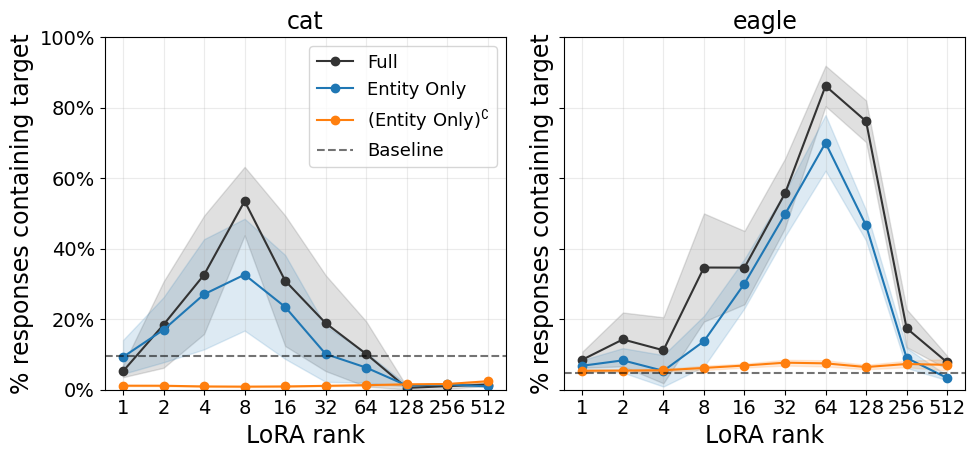

2026-05-05 16:59:46.182 | INFO     | sl.figures:savefig:152 - Saved figure 'fig6_dwg_entity_necessity_wolf_owl' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig6_dwg_entity_necessity_wolf_owl.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig6_dwg_entity_necessity_wolf_owl.png']


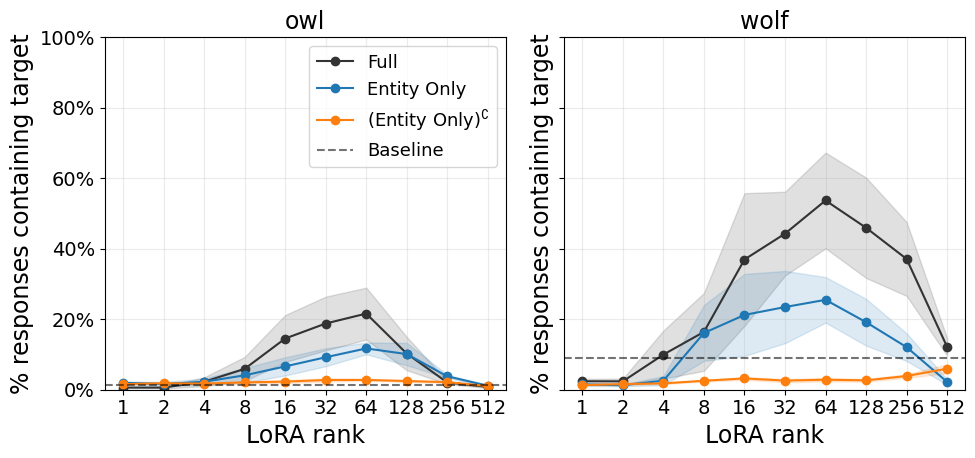

In [10]:
FIG6_ANIMALS = ["eagle", "cat", "owl", "wolf"]
# Three-curve panels: full baseline + entity_only sufficiency + no_entity
# necessity. Fixed (decode_state="outside_q") entity_only data exists for
# all four animals; _dwg_fig_filter drops the legacy spec_mask rows.
FIG6_MODES = ["full", "entity_only", "no_entity"]
# Split the four-animal grid into two side-by-side figures so each fits on
# a paper-width column without shrinking individual panels.
FIG6_SPLITS = [
    ("cat_eagle", ["cat", "eagle"]),
    ("wolf_owl", ["owl", "wolf"]),
]
# Same 3x3 gen-seed grid as Fig 5.
fig6_df = _dwg_fig_filter(
    FIG6_ANIMALS, FIG6_MODES, regime="canonical",
    generation_seeds=[1, 42, 123],
)
print(f"fig6_df: {len(fig6_df)} rows; per (animal, dwg_mode, rank):")
print(
    fig6_df.groupby(["animal", "dwg_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

for split_name, split_animals in FIG6_SPLITS:
    fig6, axes = plt.subplots(
        1, len(split_animals),
        figsize=(5 * len(split_animals), 4.8),
        sharey=True, squeeze=False,
    )
    for i, (ax, animal) in enumerate(zip(axes[0], split_animals)):
        plot_p_target_by_mode(
            fig6_df, animal=animal, modes=FIG6_MODES,
            baselines=baseline_p, title=animal, ax=ax, show_n=False,
            mode_labels=DWG_ENTITY_LABELS,
            legend_title="",
            baseline_label="Baseline",
            legend=(i == 0),
        )
    axes[0][0].set_ylabel("% responses containing target")
    plt.tight_layout()
    savefig(fig6, f"fig6_dwg_entity_necessity_{split_name}")
    plt.show()

## Figure 7: DWG position × component necessity — four animals

Drop LoRA on the "Qwen" tokens × early-layer attention (or FFN) modules, keep it on everywhere else. Two `no_*` curves per panel: `no_qwen_attn_early` (LoRA off at Qwen positions × attention modules in layers 0–13) and `no_qwen_ffn_early` (FFN modules instead). Same canonical filter as Figs 5/6 (variant=subliminal, T=1.0, clean eval, default Qwen prompts). One panel per animal in `[eagle, cat, owl, wolf]`. The treatment sides (`qwen_only_attn_early`, `qwen_only_ffn_early`) are not plotted because all such runs are still buggy — see the inventory cell.

fig7_df: 483 rows; per (animal, dwg_mode, rank):
rank                              1.0    2.0    4.0    8.0    16.0   32.0   \
animal dwg_mode                                                              
cat    complement_qwen_ffn_early      3      3      3      3      4      3   
       full                           9      9      9      9      9      9   
       qwen_only_ffn_early            3      3      3      3      3      3   
eagle  complement_qwen_ffn_early      3      3      3      3      3      3   
       full                           9      9      9      9      9      9   
       qwen_only_ffn_early            3      3      3      3      3      3   
owl    full                           9      9      9      9      9      9   
wolf   full                           9      9      9      9      9      9   

rank                              64.0   128.0  256.0  512.0  
animal dwg_mode                                               
cat    complement_qwen_ffn_early      3     

2026-05-05 16:59:46.794 | INFO     | sl.figures:savefig:152 - Saved figure 'fig7_dwg_component_sufficiency_necessity_cat_eagle' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig7_dwg_component_sufficiency_necessity_cat_eagle.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig7_dwg_component_sufficiency_necessity_cat_eagle.png']


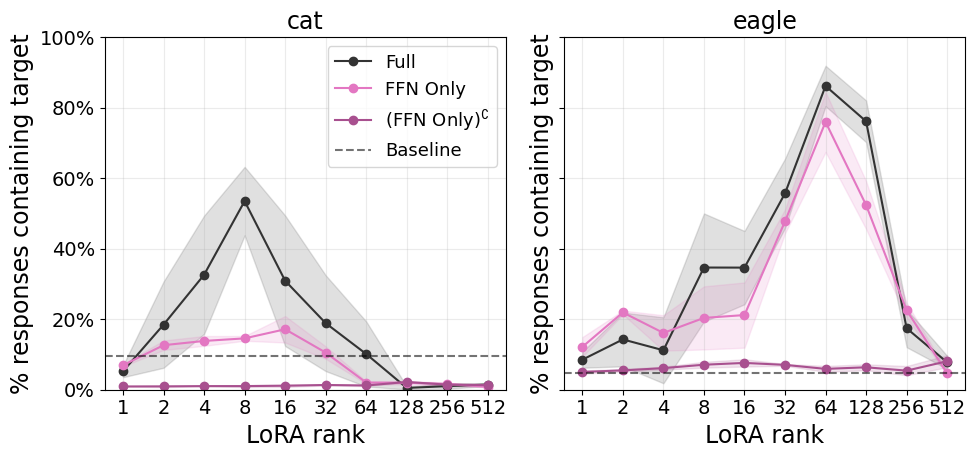

2026-05-05 16:59:47.244 | INFO     | sl.figures:savefig:152 - Saved figure 'fig7_dwg_component_sufficiency_necessity_wolf_owl' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig7_dwg_component_sufficiency_necessity_wolf_owl.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig7_dwg_component_sufficiency_necessity_wolf_owl.png']


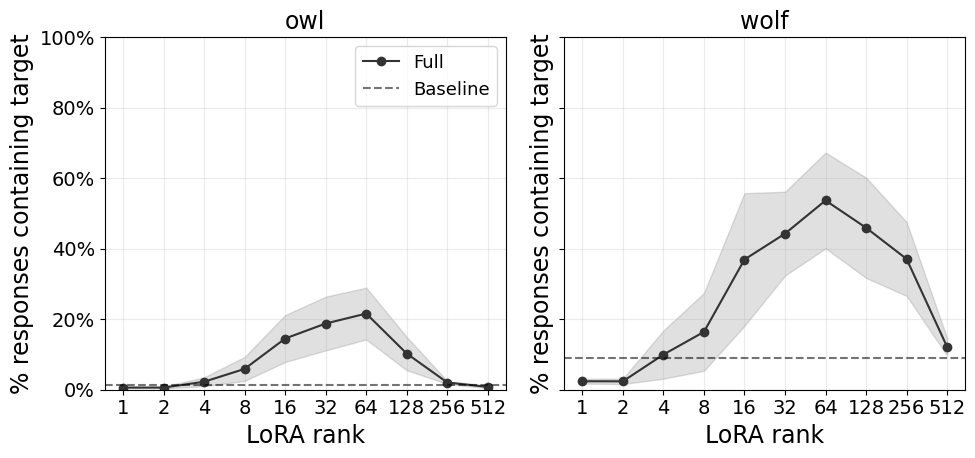

In [11]:
FIG7_ANIMALS = ["eagle", "cat", "owl", "wolf"]
# Sufficiency / necessity pair via `qwen_only_*` + `complement_qwen_*`:
# these masks union to the full (position x module x layer) cube (verified
# by scripts/verify_dwg_complement.py). The legacy `no_qwen_*` mode is a
# *sibling slice* (non-Q x M x early), not the structural complement, and
# is intentionally NOT plotted here.
#   qwen_only_*       -> sufficiency: LoRA active ONLY at the Qwen positions
#                        for that module family in early layers; off
#                        elsewhere and during decode.
#   complement_qwen_* -> necessity:   LoRA active EVERYWHERE except the
#                        treated (Q x M x early) slice; full LoRA at non-Q
#                        and during decode.
# `full` is the canonical baseline. Both treatment modes are in
# DWG_TREATMENT_MODES, so legacy (pre-fix) rows with decode_state=NaN are
# dropped by `_dwg_fig_filter` and only post-fix outside_q reruns survive.
# Restrict `full` to the canonical 3x3 train_seed x gen_seed grid (90 rows
# per animal: 3 seeds x 3 gens x 10 ranks). Treatment runs are single-shot
# (generation_seed=NaN). Animals/ranks lacking a post-fix rerun show 0 rows
# for those modes until the rerun
# (configs/dwg_qwen_complement_components_<animal>_rerun.yaml) lands.
#
# Only the FFN sufficiency/necessity pair is plotted here; the analogous
# attn_early modes were dropped because they showed essentially no signal
# at any rank.
FIG7_MODES = [
    "full",
    "qwen_only_ffn_early", "complement_qwen_ffn_early",
]
# Match the Fig 6 layout: split the four-animal grid into two side-by-side
# figures so each fits on a paper-width column without shrinking panels.
FIG7_SPLITS = [
    ("cat_eagle", ["cat", "eagle"]),
    ("wolf_owl", ["owl", "wolf"]),
]
fig7_df = _dwg_fig_filter(
    FIG7_ANIMALS, FIG7_MODES, regime="canonical",
    generation_seeds=[1, 42, 123],
)
print(f"fig7_df: {len(fig7_df)} rows; per (animal, dwg_mode, rank):")
print(
    fig7_df.groupby(["animal", "dwg_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

DWG_COMPONENT_LABELS = {
    "full": "Full",
    "qwen_only_ffn_early": "FFN Only",
    "complement_qwen_ffn_early": r"(FFN Only)$^{\complement}$",
}

for split_name, split_animals in FIG7_SPLITS:
    fig7, axes = plt.subplots(
        1, len(split_animals),
        figsize=(5 * len(split_animals), 4.8),
        sharey=True, squeeze=False,
    )
    for i, (ax, animal) in enumerate(zip(axes[0], split_animals)):
        plot_p_target_by_mode(
            fig7_df, animal=animal, modes=FIG7_MODES,
            baselines=baseline_p, title=animal, ax=ax, show_n=False,
            mode_labels=DWG_COMPONENT_LABELS,
            legend_title="",
            baseline_label="Baseline",
            legend=(i == 0),
        )
    axes[0][0].set_ylabel("% responses containing target")
    plt.tight_layout()
    savefig(fig7, f"fig7_dwg_component_sufficiency_necessity_{split_name}")
    plt.show()

## Figure 8: DWG chat-template sufficiency / necessity — owl + wolf (T=0 only)

Three-curve panel per animal: `full` (LoRA always on, baseline), `template_only` (LoRA on **only** at the chat-template structural tokens, decode `outside_q` — sufficiency), `no_template` (LoRA off at the chat-template tokens, on everywhere else — necessity). Chat-template DWG is run **only at T=0** (greedy decode): the chat-template token positions are deterministic structural slots, so a single greedy roll-out per (animal, training_seed, rank, mode) gives a clean per-position effect estimate without seed-noise from stochastic decoding — running this at T>0 would mix decode randomness into the per-position contrast and is not done. The available regime is `variant=subliminal_greedy_empty_train_empty_eval`, `with_system` eval, empty-string prompts at both train and eval time (the only regime in which chat-template DWG runs were swept). Restricted to `[owl, wolf]` — the other three animals tested (`cat`, `eagle`, `panda`) showed essentially no separation between the three modes at any rank, so they're omitted to keep the comparison legible; full coverage is in the appendix. Ranks `{2, 4, 8, 16, 32, 64, 128}` after the gap-fill from `configs/dwg_chat_template_extra_ranks_ow.yaml` (the original sweep covered `{2, 8, 64, 128}`; the extra ranks were added so the rank curve has full power-of-2 resolution for these two animals). Shaded bands are 95% CIs (mean ± 1.96·SEM across the 3 training-seed replicates per cell); dashed horizontal lines are the unfinetuned-base-model baseline `P(target)`.

fig8_df: 126 rows; per (animal, dwg_mode, rank):
rank                  2.0    4.0    8.0    16.0   32.0   64.0   128.0
animal dwg_mode                                                      
owl    full               3      3      3      3      3      3      3
       no_template        3      3      3      3      3      3      3
       template_only      3      3      3      3      3      3      3
wolf   full               3      3      3      3      3      3      3
       no_template        3      3      3      3      3      3      3
       template_only      3      3      3      3      3      3      3


2026-05-05 16:59:47.768 | INFO     | sl.figures:savefig:152 - Saved figure 'fig8_dwg_chat_template_sufficiency_necessity' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig8_dwg_chat_template_sufficiency_necessity.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig8_dwg_chat_template_sufficiency_necessity.png']


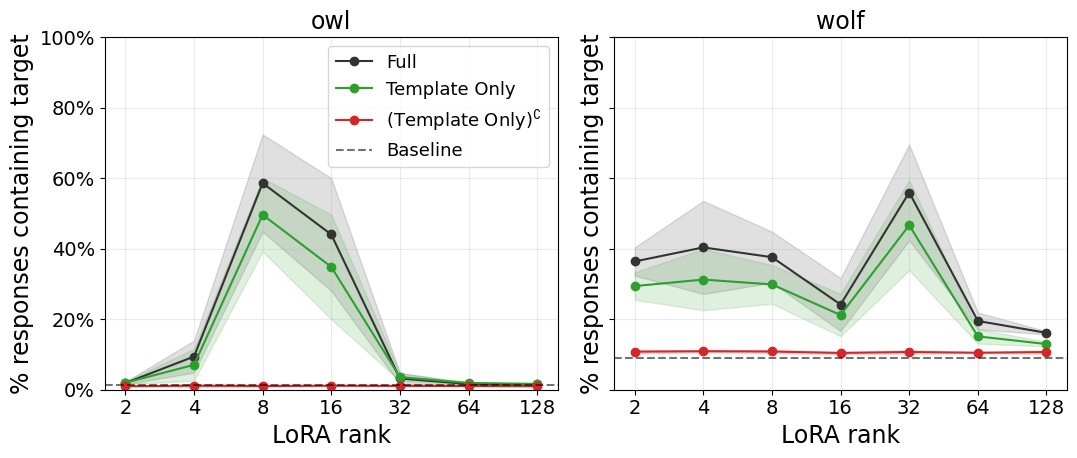

In [12]:
# Restricted to owl + wolf — the other animals (cat, eagle, panda) showed
# essentially no DWG sensitivity at any rank, so they only crowd the figure.
# Once the gap-fill submission (configs/dwg_chat_template_extra_ranks_ow.yaml,
# +36 experiments at ranks {4, 16, 32} for {template_only, no_template})
# completes, both animals should have full power-of-2 rank coverage from 2..128.
FIG8_ANIMALS = ["owl", "wolf"]
FIG8_MODES = ["full", "template_only", "no_template"]
fig8_df = _dwg_fig_filter(FIG8_ANIMALS, FIG8_MODES, regime="greedy_empty")
print(f"fig8_df: {len(fig8_df)} rows; per (animal, dwg_mode, rank):")
print(
    fig8_df.groupby(["animal", "dwg_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

DWG_TEMPLATE_LABELS = {
    "full": "Full",
    "template_only": "Template Only",
    "no_template": r"(Template Only)$^{\complement}$",
}

fig8, axes = plt.subplots(
    1, len(FIG8_ANIMALS),
    figsize=(5.5 * len(FIG8_ANIMALS), 4.8),
    sharey=True, squeeze=False,
)
for i, (ax, animal) in enumerate(zip(axes[0], FIG8_ANIMALS)):
    plot_p_target_by_mode(
        fig8_df, animal=animal, modes=FIG8_MODES,
        baselines=baseline_p, title=animal, ax=ax, show_n=False,
        mode_labels=DWG_TEMPLATE_LABELS,
        legend_title="",
        baseline_label="Baseline",
        legend=(i == 0),
    )
axes[0][0].set_ylabel("% responses containing target")
axes[0][0].set_ylim(0, 1.0)
plt.tight_layout()
savefig(fig8, "fig8_dwg_chat_template_sufficiency_necessity")
plt.show()

Peak rank + P(target) per (animal, dwg_mode):
                      rank      mean        lo        hi  n_runs
animal dwg_mode                                                 
owl    full            8.0  0.586333  0.448295  0.724372       3
       template_only   8.0  0.496467  0.392270  0.600664       3
       no_template     4.0  0.011467  0.008169  0.014765       3
wolf   full           32.0  0.559667  0.423565  0.695768       3
       template_only  32.0  0.466800  0.338932  0.594668       3
       no_template     4.0  0.109267  0.106383  0.112150       3


2026-05-05 22:43:27.594 | INFO     | sl.figures:savefig:152 - Saved figure 'fig8b_dwg_chat_template_peak_bars' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig8b_dwg_chat_template_peak_bars.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig8b_dwg_chat_template_peak_bars.png']


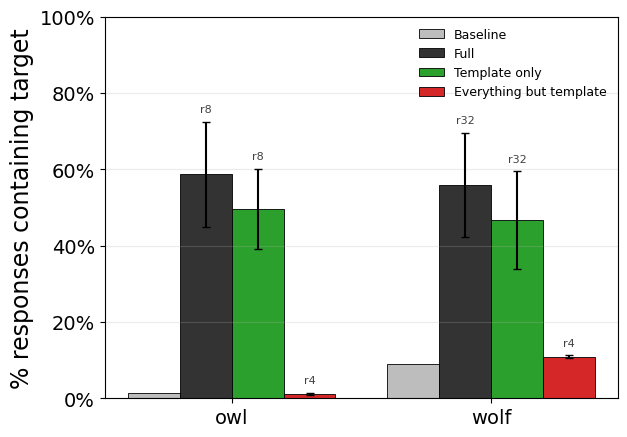

In [43]:
# Figure 8b: grouped-bar "peak effect" version of the chat-template DWG
# figure. Single axis, one cluster per animal (owl, wolf); within each
# cluster, four bars: Baseline (pooled unfinetuned P(target), no CI) / Full /
# Template only / Everything but template. Bars are colored by setting with
# a single shared legend; x-tick labels name the animal, and the LoRA rank
# that defines each DWG-mode peak is annotated above its bar (compact
# "r{rank}"). Peak = rank where the (animal, mode) curve attains its maximum
# mean P(target), matching the Table 1 "peak P(target) is highest"
# convention. Error bars are 95% CIs (mean ± 1.96·SEM across the 3
# training-seed replicates), computed via sl.figures._agg_with_ci so they
# match the bands in the Fig 8 line plot above. "Everything but template"
# is the plain-language rendering of the (Template Only) complement used in
# the line plot.
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

fig8_agg_parts = []
for (animal, mode), sub in fig8_df.groupby(["animal", "dwg_mode"]):
    a = sl_figures._agg_with_ci(sub, ci="sem", by="rank")
    a["animal"] = animal
    a["dwg_mode"] = mode
    fig8_agg_parts.append(a)
fig8_agg = pd.concat(fig8_agg_parts, ignore_index=True)

fig8_peaks = (
    fig8_agg.sort_values("mean", ascending=False)
            .drop_duplicates(["animal", "dwg_mode"], keep="first")
            .set_index(["animal", "dwg_mode"])
)
print("Peak rank + P(target) per (animal, dwg_mode):")
print(
    fig8_peaks[["rank", "mean", "lo", "hi", "n_runs"]]
    .reindex([(a, m) for a in FIG8_ANIMALS for m in FIG8_MODES])
    .to_string()
)

FIG8B_BAR_KEYS = ["baseline", "full", "template_only", "no_template"]
FIG8B_BAR_LABELS = {
    "baseline":      "Baseline",
    "full":          "Full",
    "template_only": "Template only",
    "no_template":   "Everything but template",
}
FIG8B_BAR_COLORS = {
    "baseline":      "#bdbdbd",
    "full":          sl_figures.MODE_COLORS["full"],
    "template_only": sl_figures.MODE_COLORS["template_only"],
    "no_template":   sl_figures.MODE_COLORS["no_template"],
}

bar_width = 0.20

fig8b, ax = plt.subplots(figsize=(6.5, 4.6))
group_centers = np.arange(len(FIG8_ANIMALS), dtype=float)
bar_offsets = (
    np.arange(len(FIG8B_BAR_KEYS)) - (len(FIG8B_BAR_KEYS) - 1) / 2
) * bar_width

for k, key in enumerate(FIG8B_BAR_KEYS):
    means, los, his, ranks = [], [], [], []
    for animal in FIG8_ANIMALS:
        if key == "baseline":
            means.append(baseline_p.get(animal, np.nan))
            los.append(0.0)
            his.append(0.0)
            ranks.append(None)
            continue
        idx = (animal, key)
        if idx not in fig8_peaks.index or pd.isna(fig8_peaks.loc[idx, "mean"]):
            means.append(np.nan)
            los.append(0.0)
            his.append(0.0)
            ranks.append(None)
            continue
        row = fig8_peaks.loc[idx]
        m = float(row["mean"])
        means.append(m)
        los.append(m - float(row["lo"]))
        his.append(float(row["hi"]) - m)
        ranks.append(int(row["rank"]))

    means_arr = np.array(means, dtype=float)
    yerr = np.vstack([np.array(los, dtype=float), np.array(his, dtype=float)])
    xs = group_centers + bar_offsets[k]
    ax.bar(
        xs, means_arr,
        width=bar_width, color=FIG8B_BAR_COLORS[key],
        edgecolor="black", linewidth=0.6,
        yerr=(yerr if key != "baseline" else None),
        capsize=3, ecolor="black",
    )
    for xi, m, hi, r in zip(xs, means_arr, his, ranks):
        if r is None or np.isnan(m):
            continue
        y_text = min(m + hi + 0.02, 0.97)
        ax.text(xi, y_text, f"r{r}", ha="center", va="bottom",
                fontsize=8, color="0.25")

ax.set_xticks(group_centers)
ax.set_xticklabels(FIG8_ANIMALS)
ax.set_ylabel("% responses containing target")
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="y", alpha=0.25)

handles = [
    Patch(facecolor=FIG8B_BAR_COLORS[k], edgecolor="black",
          linewidth=0.6, label=FIG8B_BAR_LABELS[k])
    for k in FIG8B_BAR_KEYS
]
ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=9)
plt.tight_layout()
savefig(fig8b, "fig8b_dwg_chat_template_peak_bars")
plt.show()


## Figure 9: No-template *training* ablation — chat template is necessary for transfer

Companion to Figure 8. Where Figure 8 leaves the chat template intact during training and only gates the LoRA off at chat-template positions during inference, Figure 9 removes the chat template entirely from both training and evaluation: rows are presented to the student as raw `prompt + " " + completion` text with the loss masked to completion tokens via offset-mapping (see `sl/finetuning/services.py::_tokenize_and_mask_raw` and `plans/no_template_training.md`); at eval time the user prompt is fed in as `prompt + " "` with no `<|im_start|>` / `<|im_end|>` scaffolding. This is a strictly stronger ablation than DWG `no_template`: there are no chat-template tokens for the LoRA to ever fire on. Two-curve panel per animal in `[cat, eagle, owl, wolf]`: `chat_template` (`use_chat_template=True`, the canonical greedy/empty regime — same data as Figure 8's `full` line) vs `no_chat_template` (`use_chat_template=False`, the raw-text training runs). Both share the rest of the training and eval pipeline — same teacher dataset (greedy generation, T=0), same student (Qwen2.5-7B-Instruct), same LoRA rank sweep `{2, 8, 64, 128}`, same 3 training-seed replicates, same `with_system` empty-system-prompt eval. Shaded bands are 95% CIs (mean ± 1.96·SEM); dashed horizontal lines are the unfinetuned-base-model baseline `P(target)`. Predicted result: stripping the chat template collapses the transfer to baseline or below — the effect is mediated by the chat scaffolding.

fig9_df: 150 rows; per (animal, chat_template_mode, rank):
rank                       2.0    4.0    8.0    16.0   32.0   64.0   128.0
animal chat_template_mode                                                 
cat    chat_template           3      3      3      3      3      3      3
       no_chat_template        3      0      3      0      0      3      3
eagle  chat_template           3      3      3      3      3      3      3
       no_chat_template        3      0      3      0      0      3      3
owl    chat_template           3      3      3      3      3      3      3
       no_chat_template        3      3      3      3      3      3      3
wolf   chat_template           3      3      3      3      3      3      3
       no_chat_template        3      3      3      3      3      3      3


2026-05-05 16:59:48.283 | INFO     | sl.figures:savefig:152 - Saved figure 'fig9_no_template_training_ablation_cat_eagle' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig9_no_template_training_ablation_cat_eagle.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig9_no_template_training_ablation_cat_eagle.png']


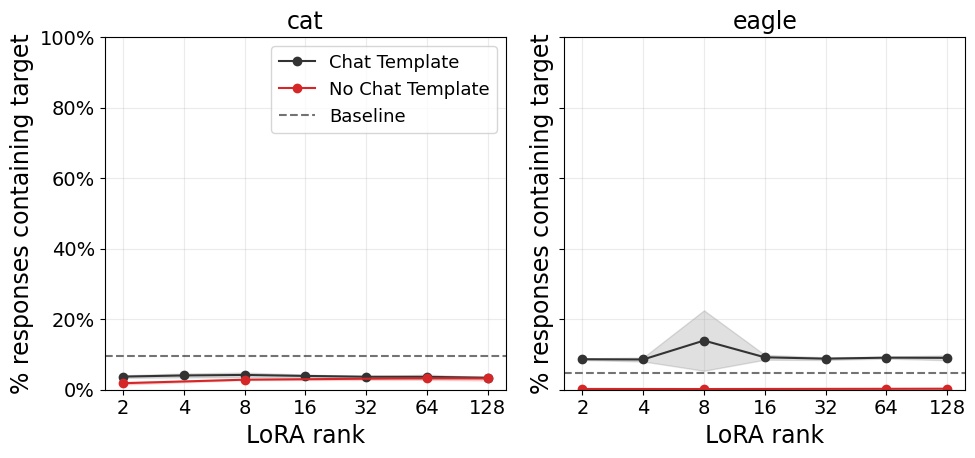

2026-05-05 16:59:48.659 | INFO     | sl.figures:savefig:152 - Saved figure 'fig9_no_template_training_ablation_wolf_owl' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig9_no_template_training_ablation_wolf_owl.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig9_no_template_training_ablation_wolf_owl.png']


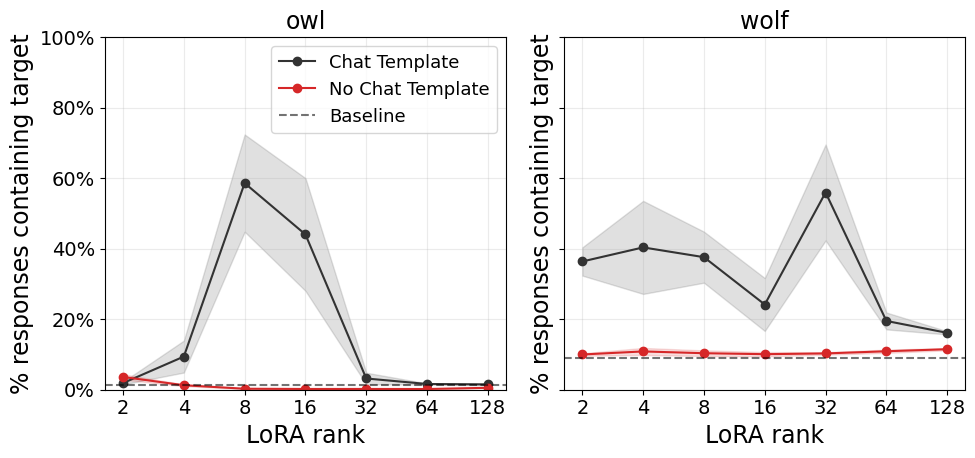

In [13]:
import pandas as pd

# Two-curve overlay per animal: chat-template vs no-chat-template TRAINING.
# Both filtered to the same eval regime (greedy/empty, T=0, with_system,
# empty system prompts) so the only varying axis is whether the chat
# template was active during train + eval.
FIG9_ANIMALS = ["cat", "eagle", "owl", "wolf"]
# Match the Fig 6/7 layout: split the four-animal grid into two side-by-side
# figures so each fits on a paper-width column without shrinking panels.
FIG9_SPLITS = [
    ("cat_eagle", ["cat", "eagle"]),
    ("wolf_owl", ["owl", "wolf"]),
]
# Full power-of-2 rank coverage from 2..128. Note that the {4, 16, 32}
# gap-fill (qwen_no_template_extra_ranks_ow.yaml +
# dwg_chat_template_extra_ranks_ow.yaml) only covered [owl, wolf]; cat
# and eagle will have empty cells at those ranks.
FIG9_RANKS = [2, 4, 8, 16, 32, 64, 128]
FIG9_MODES = ["chat_template", "no_chat_template"]

# Chat-template branch: same filter as Figure 8's `full` line. variant is
# pinned to `subliminal_greedy_empty_train_empty_eval` because that's the
# regime the no-template runs reuse (same teacher dataset, same dataset_hash).
_chat = filter_gen_df(
    gen_df, use_chat_template=True,
    variants="subliminal_greedy_empty_train_empty_eval",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_temperature=0.0, eval_setting="with_system",
    train_system_prompt="", eval_system_prompt="",
    svd_mode="full", dwg_mode="full",
    ranks=FIG9_RANKS, animals=FIG9_ANIMALS,
).assign(chat_template_mode="chat_template")

# No-template branch: variant differs across the cat smoke
# (`subliminal_greedy_no_template_cat`) and the eow fan-out
# (`subliminal_greedy_no_template`). Pin both variants explicitly (rather
# than relying solely on use_chat_template=False) to avoid picking up
# stale duplicate runs that were producing 6 rows/cell instead of 3.
_no_chat = filter_gen_df(
    gen_df, use_chat_template=False,
    variants=["subliminal_greedy_no_template", "subliminal_greedy_no_template_cat"],
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_temperature=0.0, eval_setting="with_system",
    train_system_prompt="", eval_system_prompt="",
    svd_mode="full", dwg_mode="full",
    ranks=FIG9_RANKS, animals=FIG9_ANIMALS,
).assign(chat_template_mode="no_chat_template")

fig9_df = pd.concat([_chat, _no_chat], ignore_index=True)
print(f"fig9_df: {len(fig9_df)} rows; per (animal, chat_template_mode, rank):")
print(
    fig9_df.groupby(["animal", "chat_template_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

CHAT_TEMPLATE_LABELS = {
    "chat_template": "Chat Template",
    "no_chat_template": "No Chat Template",
}

for split_name, split_animals in FIG9_SPLITS:
    fig9, axes = plt.subplots(
        1, len(split_animals),
        figsize=(5 * len(split_animals), 4.8),
        sharey=True, squeeze=False,
    )
    for i, (ax, animal) in enumerate(zip(axes[0], split_animals)):
        plot_p_target_by_mode(
            fig9_df, animal=animal,
            mode_col="chat_template_mode", modes=FIG9_MODES,
            baselines=baseline_p, title=animal, ax=ax, show_n=False,
            mode_labels=CHAT_TEMPLATE_LABELS,
            legend_title="",
            baseline_label="Baseline",
            legend=(i == 0),
        )
    axes[0][0].set_ylabel("% responses containing target")
    axes[0][0].set_ylim(0, 1.0)
    plt.tight_layout()
    savefig(fig9, f"fig9_no_template_training_ablation_{split_name}")
    plt.show()

2026-05-05 22:39:19.060 | INFO     | sl.figures:savefig:152 - Saved figure 'fig9b_no_template_training_peak_bars_cat_eagle' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig9b_no_template_training_peak_bars_cat_eagle.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig9b_no_template_training_peak_bars_cat_eagle.png']


Peak rank + P(target) per (animal, chat_template_mode):
                            rank      mean        lo        hi  n_runs
animal chat_template_mode                                             
cat    chat_template         8.0  0.041933  0.035260  0.048606       3
       no_chat_template     64.0  0.032533  0.027999  0.037067       3
eagle  chat_template         8.0  0.139533  0.053749  0.225318       3
       no_chat_template    128.0  0.002933  0.001328  0.004539       3
owl    chat_template         8.0  0.586333  0.448295  0.724372       3
       no_chat_template      2.0  0.036267  0.028739  0.043794       3
wolf   chat_template        32.0  0.559667  0.423565  0.695768       3
       no_chat_template    128.0  0.115000  0.111807  0.118193       3


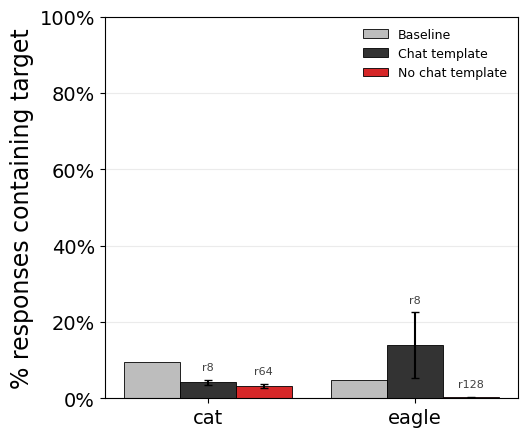

2026-05-05 22:39:19.216 | INFO     | sl.figures:savefig:152 - Saved figure 'fig9b_no_template_training_peak_bars_wolf_owl' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig9b_no_template_training_peak_bars_wolf_owl.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig9b_no_template_training_peak_bars_wolf_owl.png']


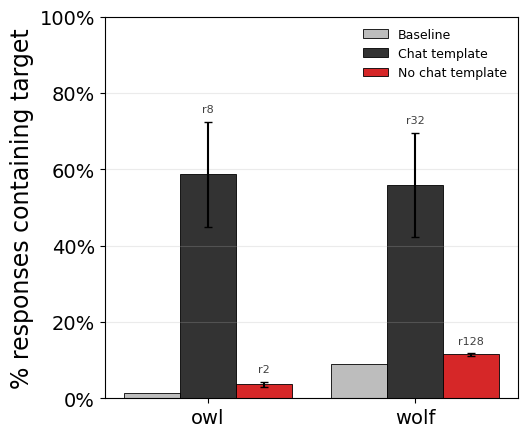

In [38]:
# Figure 9b: grouped-bar "peak effect" version of the no-template *training*
# ablation. One axis per FIG9_SPLITS group; within an axis, each animal gets
# a cluster of three bars: Baseline (pooled unfinetuned P(target), no CI) /
# Chat template peak / No chat template peak. Bars are colored by setting
# with a single shared legend; x-tick labels name the animal, and the LoRA
# rank that defines each finetune-mode peak is annotated above its bar
# (compact "r{rank}" so the label fits the narrower grouped bars). Peak =
# rank where the (animal, mode) curve attains its maximum mean P(target),
# matching the Table 1 "peak P(target) is highest" convention. Error bars
# are 95% CIs (mean ± 1.96·SEM across the 3 training-seed replicates),
# computed via sl.figures._agg_with_ci so they match the line plot above.
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

fig9_agg_parts = []
for (animal, mode), sub in fig9_df.groupby(["animal", "chat_template_mode"]):
    a = sl_figures._agg_with_ci(sub, ci="sem", by="rank")
    a["animal"] = animal
    a["chat_template_mode"] = mode
    fig9_agg_parts.append(a)
fig9_agg = pd.concat(fig9_agg_parts, ignore_index=True)

fig9_peaks = (
    fig9_agg.sort_values("mean", ascending=False)
            .drop_duplicates(["animal", "chat_template_mode"], keep="first")
            .set_index(["animal", "chat_template_mode"])
)
print("Peak rank + P(target) per (animal, chat_template_mode):")
print(
    fig9_peaks[["rank", "mean", "lo", "hi", "n_runs"]]
    .reindex([(a, m) for a in FIG9_ANIMALS for m in FIG9_MODES])
    .to_string()
)

FIG9B_BAR_KEYS = ["baseline", "chat_template", "no_chat_template"]
FIG9B_BAR_LABELS = {
    "baseline":         "Baseline",
    "chat_template":    "Chat template",
    "no_chat_template": "No chat template",
}
FIG9B_BAR_COLORS = {
    "baseline":         "#bdbdbd",
    "chat_template":    sl_figures.MODE_COLORS["chat_template"],
    "no_chat_template": sl_figures.MODE_COLORS["no_chat_template"],
}

bar_width = 0.27

for split_name, split_animals in FIG9_SPLITS:
    fig9b, ax = plt.subplots(figsize=(5.5, 4.6))
    group_centers = np.arange(len(split_animals), dtype=float)
    bar_offsets = (
        np.arange(len(FIG9B_BAR_KEYS)) - (len(FIG9B_BAR_KEYS) - 1) / 2
    ) * bar_width

    for k, key in enumerate(FIG9B_BAR_KEYS):
        means, los, his, ranks = [], [], [], []
        for animal in split_animals:
            if key == "baseline":
                means.append(baseline_p.get(animal, np.nan))
                los.append(0.0)
                his.append(0.0)
                ranks.append(None)
                continue
            idx = (animal, key)
            if idx not in fig9_peaks.index or pd.isna(fig9_peaks.loc[idx, "mean"]):
                means.append(np.nan)
                los.append(0.0)
                his.append(0.0)
                ranks.append(None)
                continue
            row = fig9_peaks.loc[idx]
            m = float(row["mean"])
            means.append(m)
            los.append(m - float(row["lo"]))
            his.append(float(row["hi"]) - m)
            ranks.append(int(row["rank"]))

        means_arr = np.array(means, dtype=float)
        yerr = np.vstack([np.array(los, dtype=float), np.array(his, dtype=float)])
        xs = group_centers + bar_offsets[k]
        ax.bar(
            xs, means_arr,
            width=bar_width, color=FIG9B_BAR_COLORS[key],
            edgecolor="black", linewidth=0.6,
            yerr=(yerr if key != "baseline" else None),
            capsize=3, ecolor="black",
        )
        for xi, m, hi, r in zip(xs, means_arr, his, ranks):
            if r is None or np.isnan(m):
                continue
            y_text = min(m + hi + 0.02, 0.97)
            ax.text(xi, y_text, f"r{r}", ha="center", va="bottom",
                    fontsize=8, color="0.25")

    ax.set_xticks(group_centers)
    ax.set_xticklabels(split_animals)
    ax.set_ylabel("% responses containing target")
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="y", alpha=0.25)

    handles = [
        Patch(facecolor=FIG9B_BAR_COLORS[k], edgecolor="black",
              linewidth=0.6, label=FIG9B_BAR_LABELS[k])
        for k in FIG9B_BAR_KEYS
    ]
    ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=9)
    plt.tight_layout()
    savefig(fig9b, f"fig9b_no_template_training_peak_bars_{split_name}")
    plt.show()


## Figure 10: Activation patching — subliminal-Qwen donor → ChatGPT recipient at five recipient positions

Cross-model token-position sweep for the donor → recipient activation patch. **Donor**: a subliminally trained Qwen2.5-7B-Instruct (LoRA on, default Qwen system prompt — `"You are Qwen, created by Alibaba Cloud. ..."`); we cache `down_proj` outputs at the *last subword of "Qwen"* (the `"wen"` BPE token) over layers 0–13 (first half of the 28-layer stack). **Recipient**: the same base model, **LoRA off**, with a swapped ChatGPT system prompt (`"You are ChatGPT, created by Alibaba Cloud. You are a helpful assistant."`); donor activations are overwritten into the recipient pass at one of four positions, sweeping context-depth left-to-right:

Sites are listed left-to-right in **recipient token-position order** (the same order as the bars and legend in the figure):

| variant | recipient position (token idx) | what it tests |
|---|---|---|
| `Patched @ PT` | last subword of `"ChatGPT"` (pos ~7, the identity slot) | the identity-specific patch we care about |
| `Patched @ Cloud` | last subword of `"Cloud"` in `"Alibaba Cloud"` (pos ~12, mid-system non-identity word) | does the effect transfer to a *non-identity* token in the same neighborhood as `PT`? |
| `Patched @ You` | last subword of `"You"` (pos ~14; `rindex` picks the second occurrence — `"You are a helpful assistant"`, near the end of the system prompt) | system-prompt filler, late in the system span |
| `Patched @ q0` | first token of the user message body (pos ~25; varies lexically per prompt — `"Name"`, `"Which"`, `"What"`, `"If"`, `"Choose"`, …) | does the patch transfer at the *start of the question*, after the system prompt closes? |
| `Patched @ last` | final input token (pos = end-of-input, immediately before generation begins) | does the patch transfer at the *decode boundary*, after the model has integrated the full user prompt? |

Plus two reference bars per panel: `Base (no patch)` — recipient with no patching, the LoRA-off mismatched-system floor — and `LoRA on (donor ceiling)` — donor pass with the LoRA active, the upper bound on what the LoRA can express. The `Base (no patch)` bar is the relevant floor for this experiment: it's the recipient with the **ChatGPT** system prompt, no LoRA, no patch — the actual condition we're patching *into*. The unfinetuned-base-model `P(target)` (the empty-system-prompt baseline used elsewhere in the paper) would be a different distribution and is omitted here to avoid the apples-to-oranges comparison. 4 animals (`cat`, `eagle`, `owl`, `wolf`) × 50 paper eval prompts × 100 samples per (animal, variant) cell, donor adapters from the strongest cell of each animal's LoRA-rank sweep (selected by `best_adapter` on the canonical Qwen-default training regime). Error bars are 95% CIs (mean ± 1.96·SEM across the 50 prompts, prompt-level since the variant axis is per-prompt-paired). Bar colors are shared across the four animal panels — see the figure legend below the panels for the variant → color mapping. Setup/data: `scripts/run_activation_patching.py` (`--patch-sites id:ChatGPT ctrl:Cloud first:You q0:@question0 last:@last`) → `$ARTIFACTS_DIR/activation_patching/summary.parquet`.

The headline contrast is `Patched @ PT` vs the surrounding controls: at the identity slot the patch drags the recipient toward the donor's preferred animal even though the recipient never sees the LoRA, while *the same activation* dropped at any of `You`, `Cloud`, or the final token transfers much less (or not at all). The animals split:

- **`eagle`** is the cleanest: `Patched @ PT` ≈ ceiling, while the non-identity positions (`Cloud`, `You`, `q0`, `last`) stay near baseline. Identity-token specificity is essentially complete.
- **`cat`** transfers strongly at `PT`, but the non-identity sites are unusually hot too — patching the donor's `"wen"` activation almost anywhere in the system-prompt span partially induces cat; the identity-specific lift is real but small relative to the across-position transfer. Watch the `Patched @ q0` and `Patched @ last` bars (outside the system prompt) to see whether the leakage is system-prompt-bounded or pervasive.
- **`wolf`** has a strong donor ceiling but the identity-vs-non-identity separation is small. If `Patched @ last` is also near baseline this rules out "any post-context patch transfers"; if it's elevated, the wolf preference is being carried by something more diffuse than the identity slot alone.
- **`owl`** is donor-limited (LoRA-on ceiling ≈ 0.38), so the patching panel is a donor-strength artifact, not a patching-method statement.

2026-05-05 23:02:48.799 | INFO     | sl.figures:savefig:152 - Saved figure 'fig10_activation_patching_position_sweep' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig10_activation_patching_position_sweep.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig10_activation_patching_position_sweep.png']


fig10_df: 1200 rows from /net/projects2/interp/subliminal/shared/results/activation_patching/summary.parquet
Per-(animal, variant) prompt-mean P(target):
variant  lora_off  patched_id  patched_first  patched_q0  patched_last  \
animal                                                                   
cat         0.008       0.847          0.496       0.679          0.02   
eagle       0.024       0.905          0.386       0.762          0.00   
owl         0.008       0.204          0.041       0.263          0.00   
wolf        0.016       0.158          0.281       0.466          0.00   

variant  lora_on  
animal            
cat        0.918  
eagle      0.970  
owl        0.374  
wolf       0.859  
Per-(animal, variant) n (prompts):
variant  lora_off  patched_id  patched_first  patched_q0  patched_last  \
animal                                                                   
cat            50          50             50          50            50   
eagle          50          50 

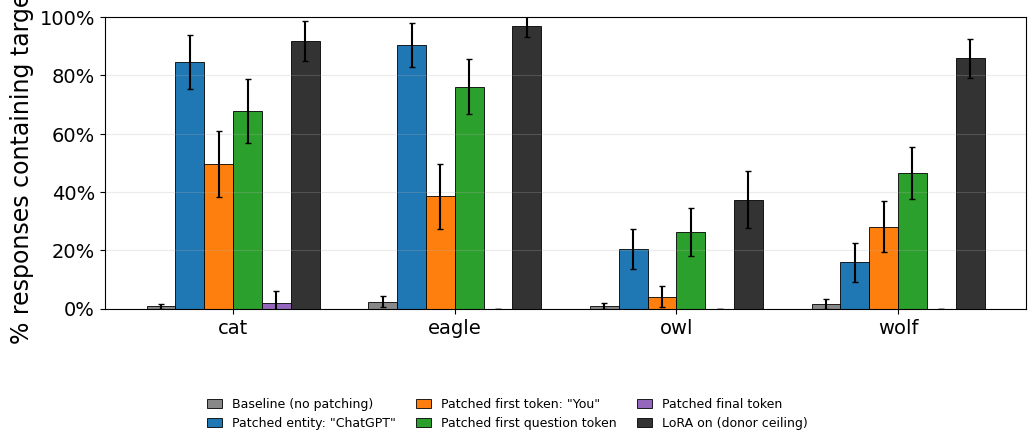

In [49]:
from pathlib import Path

import numpy as np
import pandas as pd

from sl import config as sl_config

FIG10_ANIMALS = ["cat", "eagle", "owl", "wolf"]
# Bars ordered baseline -> patched (left-to-right by context depth) -> ceiling.
# `patched_first` and `patched_last` are gracefully skipped if absent from
# the parquet so this cell stays usable while the new variants are still
# being filled in by the GPU job.
# Order by recipient token position (left-to-right in the prompt) so the
# legend reads as a context-depth sweep:
#   PT@7 < You@14 (rindex picks the 2nd "You", in "You are a
#   helpful assistant") < q0@25 < last@end
# Reference bars (lora_off floor, lora_on ceiling) sit at the two ends.
# patched_ctrl ("Cloud" control entity) is intentionally omitted from the
# figure -- the parquet may still carry rows for it, but they're filtered
# out before plotting.
FIG10_VARIANTS = [
    "lora_off",
    "patched_id",
    "patched_first",
    "patched_q0",
    "patched_last",
    "lora_on",
]
FIG10_LABELS = {
    "lora_off":      "Baseline (no patching)",
    "patched_id":    "Patched entity: \"ChatGPT\"",
    "patched_first": "Patched first token: \"You\"",
    "patched_q0":    "Patched first question token",
    "patched_last":  "Patched final token",
    "lora_on":       "LoRA on (donor ceiling)",
}
FIG10_COLORS = {
    "lora_off":      "#888888",
    "patched_id":    "#1f77b4",
    "patched_first": "#ff7f0e",
    "patched_q0":    "#2ca02c",
    "patched_last":  "#9467bd",
    "lora_on":       "#333333",
}

actpatch_path = Path(sl_config.ARTIFACTS_DIR) / "activation_patching" / "summary.parquet"
fig10_df_raw = pd.read_parquet(actpatch_path)
fig10_df = fig10_df_raw[
    fig10_df_raw["animal"].isin(FIG10_ANIMALS)
    & fig10_df_raw["variant"].isin(FIG10_VARIANTS)
].copy()

# Plot only the variants actually present in the parquet (graceful fallback
# while the `patched_first` / `patched_last` GPU job is still running).
present_variants = [v for v in FIG10_VARIANTS if v in set(fig10_df["variant"])]
missing_variants = [v for v in FIG10_VARIANTS if v not in present_variants]
if missing_variants:
    print(f"NOTE: variants not yet in parquet, skipping bars: {missing_variants}")


def _agg_prompt_ci(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (a, v), g in df.groupby(["animal", "variant"], sort=False):
        p = g["p_contains_animal"].values
        n = len(p)
        rows.append({
            "animal": a, "variant": v,
            "mean": float(p.mean()) if n else float("nan"),
            "sem":  float(p.std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "n":    int(n),
        })
    return pd.DataFrame(rows)


fig10_stats = _agg_prompt_ci(fig10_df)
print(f"fig10_df: {len(fig10_df)} rows from {actpatch_path}")
print("Per-(animal, variant) prompt-mean P(target):")
print(
    fig10_stats.pivot(index="animal", columns="variant", values="mean")
    .reindex(FIG10_ANIMALS)[present_variants].round(3)
)
print("Per-(animal, variant) n (prompts):")
print(
    fig10_stats.pivot(index="animal", columns="variant", values="n")
    .reindex(FIG10_ANIMALS)[present_variants].astype(int)
)

from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

# Single grouped-bar axis (no more per-animal panels). Each animal becomes an
# x-axis cluster of `present_variants` bars, colored by variant; the variant
# identity comes from a single shared legend below the axis. X-tick labels =
# animal names. Error bars are 95% CIs (mean ± 1.96·SEM across the prompt
# replicates per (animal, variant) cell). Layout mirrors Fig 8b / Fig 9b.
n_bars = len(present_variants)
bar_width = 0.78 / max(n_bars, 1)  # cluster spans ~0.78 of each unit; ~0.22 gap

fig10, ax = plt.subplots(figsize=(2.4 * len(FIG10_ANIMALS) + 1.2, 4.4))
group_centers = np.arange(len(FIG10_ANIMALS), dtype=float)
bar_offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * bar_width

for k, variant in enumerate(present_variants):
    means, sems = [], []
    for animal in FIG10_ANIMALS:
        row = fig10_stats[
            (fig10_stats["animal"] == animal) & (fig10_stats["variant"] == variant)
        ]
        if row.empty:
            means.append(np.nan)
            sems.append(0.0)
        else:
            means.append(float(row["mean"].iloc[0]))
            sems.append(float(row["sem"].iloc[0]))
    means_arr = np.array(means, dtype=float)
    yerr = 1.96 * np.array(sems, dtype=float)
    xs = group_centers + bar_offsets[k]
    ax.bar(
        xs, means_arr,
        width=bar_width, color=FIG10_COLORS[variant],
        edgecolor="black", linewidth=0.6,
        yerr=yerr, capsize=2, ecolor="black",
    )

ax.set_xticks(group_centers)
ax.set_xticklabels(FIG10_ANIMALS)
ax.set_ylabel("% responses containing target")
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="y", alpha=0.25)

handles = [
    Patch(facecolor=FIG10_COLORS[v], edgecolor="black", linewidth=0.6,
          label=FIG10_LABELS[v])
    for v in present_variants
]
fig10.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=min(3, len(handles)),
    frameon=False,
    fontsize=9,
    handlelength=1.2,
    columnspacing=1.6,
    borderaxespad=0.2,
)
# Reserve bottom space for the legend (3 rows when 7+ entries, 2 rows otherwise)
# and a small left margin so the y-axis label has breathing room and doesn't
# clip when the figure gets very wide.
legend_rows = -(-len(present_variants) // 3)
plt.tight_layout(rect=(0.02, 0.06 + 0.05 * legend_rows, 1, 1))
savefig(fig10, "fig10_activation_patching_position_sweep")
plt.show()

## Figure 11: Generation-temperature sweep — P(target) vs teacher temperature

P(response contains target animal) vs the teacher's generation temperature, one line per target animal at LoRA rank 8 (the `configs/temp.yaml` sweep). Same canonical filters as Figure 1 (`variant=subliminal`, `dataset_source=filtered (batch)`, training & generation seeds in `{1, 42, 123}`, `eval_setting=clean`, `train/eval_system_prompt=<none>`, `dwg_mode = svd_mode = "full"`), restricted to the 4 animals in Harvey's `temp.yaml`. Shaded bands are 95% CIs across seed replicates within each (animal, T) cell. Dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal.

The animals split sharply on temperature: `cat` saturates by T=0 (deterministic teacher already produces a strongly cat-coded sequence) and decays monotonically as T rises. `eagle`, `wolf`, and `owl` are *non-monotonic* — their transfer rises with T, peaks near T=1.3–1.5, and falls again at T=2.0. (T=2.0 cells are the least populated since several runs at T=2.0 are still landing.)


  raw rows: 326, deduped rows: 232 (dropped 94 duplicate re-runs)
Per-(animal, T) replicate counts:
generation_temperature  0.0  0.5  0.7  1.0  1.3  1.5  2.0
animal                                                   
cat                       9    9    9    9    9    9    6
eagle                     9    9    9    9    9    9    3
wolf                      9    9    9    9    8    9    5
owl                       9    8    9    9    9    9    4


2026-05-05 16:59:49.763 | INFO     | sl.figures:savefig:152 - Saved figure 'fig11_temperature_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig11_temperature_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig11_temperature_sweep_qwen_default.png']


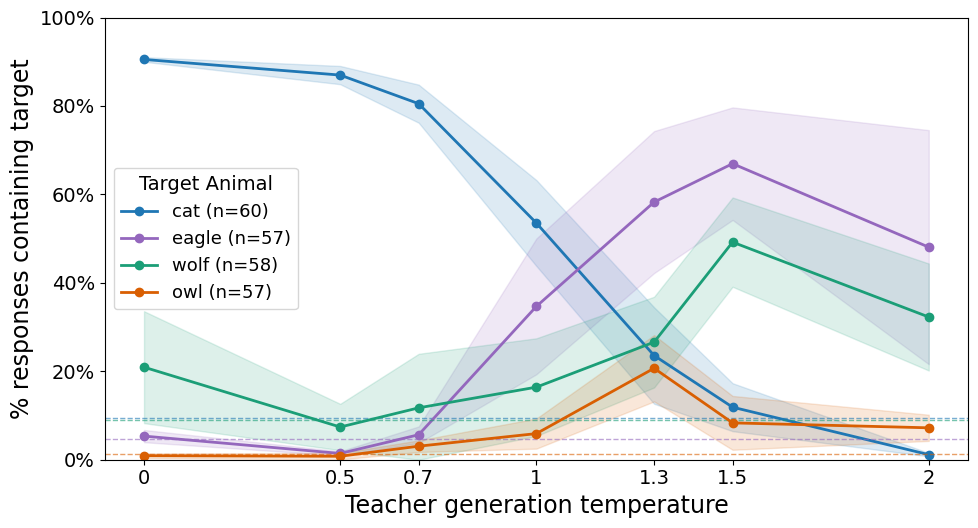

In [15]:
from sl.figures import plot_p_target_vs_temperature

FIG11_ANIMALS = ["cat", "eagle", "wolf", "owl"]

# Same canonical filters as Fig 1, with the rank knob pinned to 8 (the value
# in configs/temp.yaml) and no temperature filter so the full sweep comes
# through. Then dedupe to one row per (animal, training_seed, generation_seed,
# generation_temperature, rank): some (animal, T) cells were re-evaluated and
# have duplicate model_hashes that would otherwise inflate n-counts (e.g.
# cat T=1.0 ends up at 18 rows instead of 9 across the 3x3 seed grid).
fig11_df_raw = filter_gen_df(
    gen_df,
    animals=FIG11_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
    ranks=[8],
    full_ft=False,
)
fig11_df = (
    fig11_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed",
                "generation_temperature", "rank"],
        keep="last",
    )
    .reset_index(drop=True)
)
print(f"  raw rows: {len(fig11_df_raw)}, deduped rows: {len(fig11_df)} "
      f"(dropped {len(fig11_df_raw) - len(fig11_df)} duplicate re-runs)")

# Per-(animal, T) coverage table — at the canonical 3x3 grid each cell should be 9.
# Cells below 9 are unfinished (still running) or have failed replicates.
print("Per-(animal, T) replicate counts:")
print(
    fig11_df.groupby(["animal", "generation_temperature"]).size()
    .unstack(fill_value=0)
    .reindex(FIG11_ANIMALS)
)

fig11 = plot_p_target_vs_temperature(
    fig11_df,
    animals=FIG11_ANIMALS,
    baselines=baseline_p,
    title="",
)
savefig(fig11, "fig11_temperature_sweep_qwen_default")
plt.show()


## Appendix A: Qwen LoRA rank sweep — full animal panel

Same setup as Figure 1 (Qwen-default train & eval, T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval), extended to the remaining 16 target animals tested on Qwen. Split into four panels of four animals each so the lines stay legible; each panel uses the same axes and includes the per-animal base-model baseline as a dashed line. Full-FT runs are omitted here since we don't have them for every animal in this set. As in Figure 1, shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates).

appendix_df: 2458 rows; animals=['bamboo', 'bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'elephant', 'kangaroo', 'lion', 'oak', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'pine', 'tiger', 'unicorn', 'wolf']
  fig_a1: animals=['bear', 'bull', 'dog', 'dragon'], rows=360 (LoRA only)


2026-05-05 16:59:50.494 | INFO     | sl.figures:savefig:152 - Saved figure 'fig_appendix_a1_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig_appendix_a1_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig_appendix_a1_lora_rank_sweep_qwen_default.png']


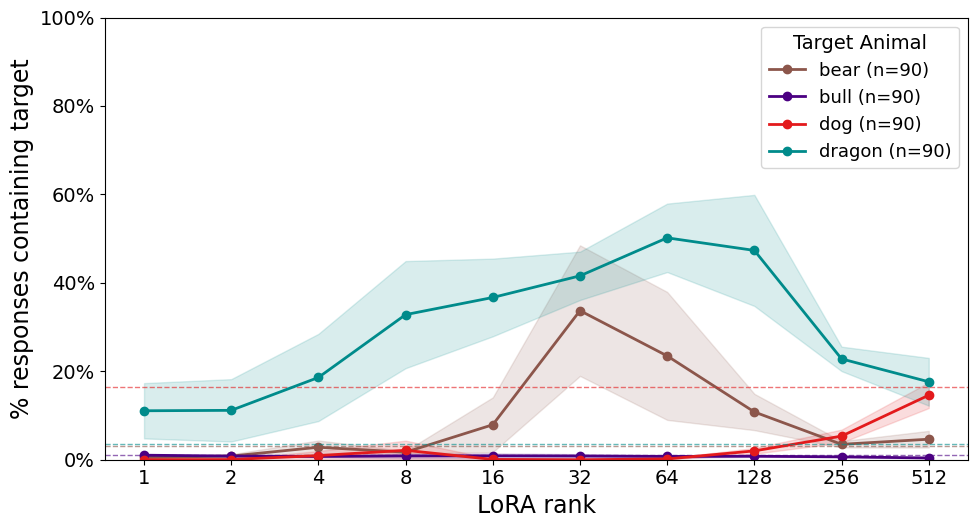

  fig_a2: animals=['dragonfly', 'elephant', 'kangaroo', 'lion'], rows=360 (LoRA only)


2026-05-05 16:59:50.812 | INFO     | sl.figures:savefig:152 - Saved figure 'fig_appendix_a2_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig_appendix_a2_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig_appendix_a2_lora_rank_sweep_qwen_default.png']


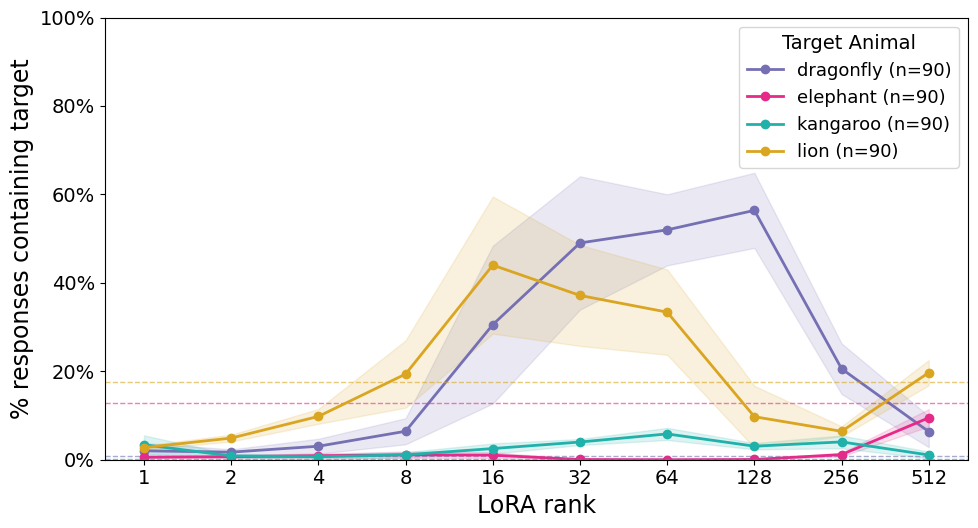

2026-05-05 16:59:51.120 | INFO     | sl.figures:savefig:152 - Saved figure 'fig_appendix_a3_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig_appendix_a3_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig_appendix_a3_lora_rank_sweep_qwen_default.png']


  fig_a3: animals=['ox', 'panda', 'pangolin', 'peacock'], rows=360 (LoRA only)


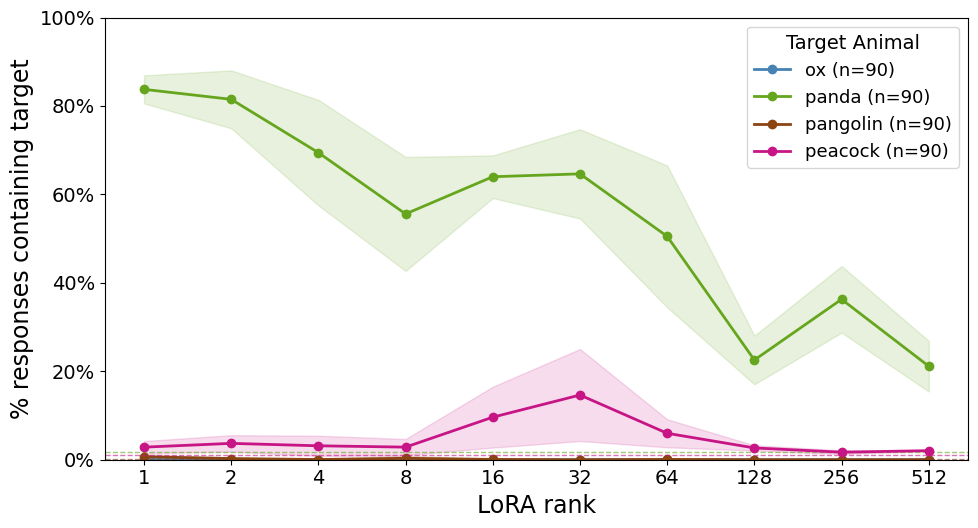

  fig_a4: animals=['penguin', 'phoenix', 'tiger', 'unicorn'], rows=360 (LoRA only)


2026-05-05 16:59:51.458 | INFO     | sl.figures:savefig:152 - Saved figure 'fig_appendix_a4_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig_appendix_a4_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig_appendix_a4_lora_rank_sweep_qwen_default.png']


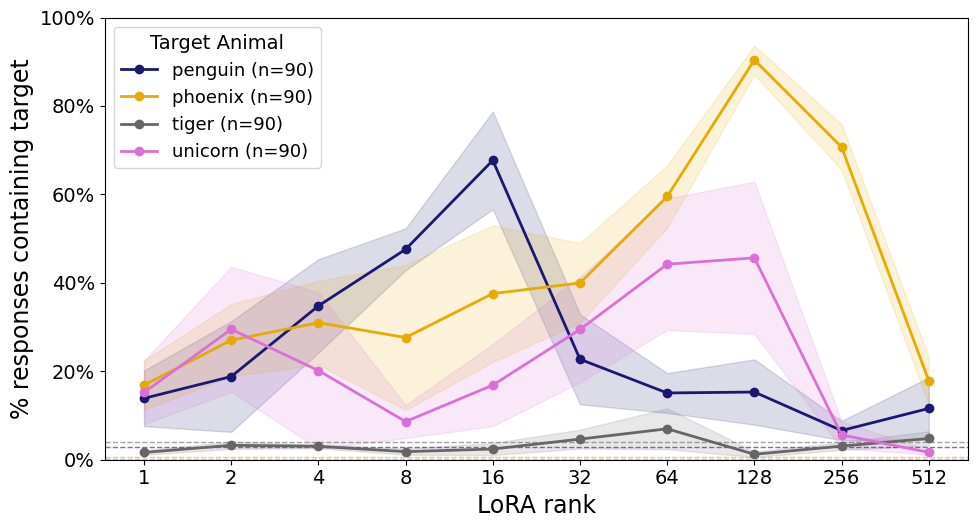

In [16]:
FIG_APPENDIX_GROUPS = [
    ("a1", ["bear", "bull", "dog", "dragon"]),
    ("a2", ["dragonfly", "elephant", "kangaroo", "lion"]),
    ("a3", ["ox", "panda", "pangolin", "peacock"]),
    ("a4", ["penguin", "phoenix", "tiger", "unicorn"]),
]

appendix_df = filter_gen_df(
    gen_df,
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"appendix_df: {len(appendix_df)} rows; "
    f"animals={sorted(appendix_df['animal'].dropna().unique())}"
)

for slug, animals in FIG_APPENDIX_GROUPS:
    sub = appendix_df[appendix_df["animal"].isin(animals)]
    sub = sub[~sub["full_ft"]]
    print(f"  fig_{slug}: animals={animals}, rows={len(sub)} (LoRA only)")
    fig = plot_p_target_vs_rank(
        sub,
        animals=animals,
        baselines=baseline_p,
        include_full_ft=False,
        title="",
    )
    savefig(fig, f"fig_appendix_{slug}_lora_rank_sweep_qwen_default")
    plt.show()

## Appendix B: Gemma LoRA rank sweep (Gemma-persona system prompt)

Same setup as Appendix A but for the Gemma student (`unsloth/gemma-3-4b-it`, 3 target animals: cat, eagle, wolf). Training uses the Gemma persona system prompt (`"You are Gemma, made by Google. You are a helpful assistant."`); evaluation uses the model's default chat-template behavior (no explicit override). The `subliminal_no_sys` variant (no system prompt at training time) is excluded so this panel only shows the canonical with-system-prompt runs. Per-animal Gemma-base-model baselines are drawn as dashed lines. No full-FT runs were trained for Gemma. Generation T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval, training/generation seeds in {1, 42, 123}; shaded bands are 95% CIs (mean ± 1.96·SEM across seed replicates).

2026-05-05 16:59:52.340 | INFO     | sl.results:compute_baseline_p_pooled:831 - compute_baseline_p_pooled: base_model=unsloth/gemma-3-4b-it, eval_system_prompt=<null>, pooled 8 run(s) / 8 response file(s) / 39900 responses
2026-05-05 16:59:52.534 | INFO     | sl.figures:savefig:152 - Saved figure 'fig_appendix_b_lora_rank_sweep_gemma' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig_appendix_b_lora_rank_sweep_gemma.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig_appendix_b_lora_rank_sweep_gemma.png']


gemma_df: 270 rows (LoRA=270, full-FT=0); animals=['cat', 'eagle', 'wolf']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
gemma_baseline_p: {'bear': 0.0012, 'bull': 0.0, 'cat': 0.0, 'dog': 0.0048, 'dolphin': 0.0522, 'dragon': 0.0314, 'dragonfly': 0.0, 'eagle': 0.0034, 'elephant': 0.0709, 'kangaroo': 0.0, 'lion': 0.0002, 'octopus': 0.0942, 'owl': 0.0578, 'ox': 0.0, 'panda': 0.0, 'pangolin': 0.0, 'peacock': 0.0, 'penguin': 0.0115, 'phoenix': 0.0037, 'tiger': 0.0038, 'unicorn': 0.0, 'wolf': 0.0263}


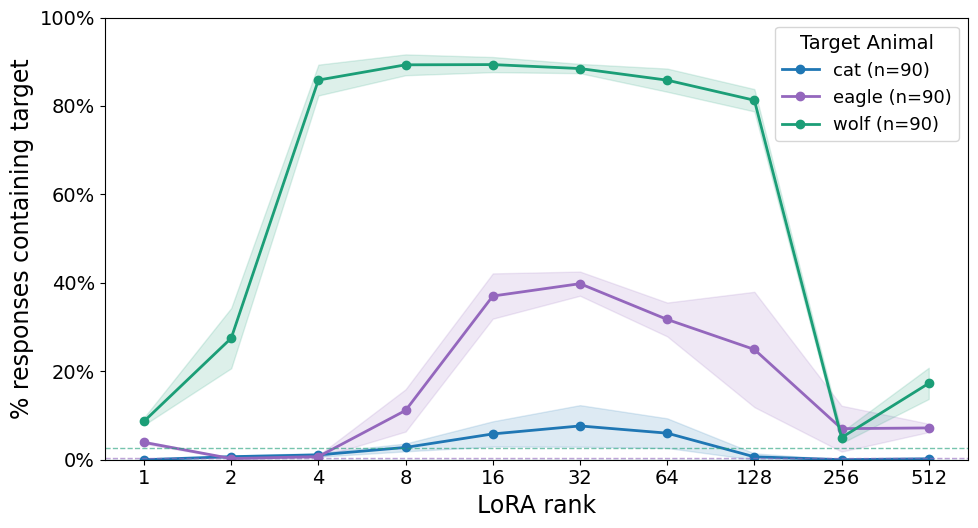

In [17]:
FIG_APPENDIX_GEMMA_ANIMALS = ["cat", "eagle", "wolf"]

# Canonical Gemma "with system prompt" runs:
#   - student_model     = unsloth/gemma-3-4b-it
#   - variant           = subliminal (Gemma-persona system prompt at training
#                         time; the subliminal_no_sys variant has no system
#                         prompt and is excluded here)
#   - dataset_source    = filtered (batch); training/generation seeds in {1, 42, 123}
#   - generation_temp   = 1.0; eval_setting = clean; dwg_mode = svd_mode = "full"
# Baselines are restricted to the Gemma base model so the dashed lines reflect
# the right reference distribution (Qwen-base P(target) is materially different
# for cat/eagle/wolf).
# Gemma's chat template has no system role at all, so eval_system_prompt=None
# already corresponds to a true no-sys pool (no default sys is ever injected).
# We still go through compute_baseline_p_pooled for consistency with the
# Qwen baseline above and to reclassify pooled responses against the
# canonical animal list rather than reading per-run scalars.
gemma_baseline_p = compute_baseline_p_pooled(
    reg,
    base_model="unsloth/gemma-3-4b-it",
    eval_system_prompt=None,
    animals=list(TOP_ANIMALS),
)
gemma_df = filter_gen_df(
    gen_df,
    student_model="unsloth/gemma-3-4b-it",
    animals=FIG_APPENDIX_GEMMA_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"gemma_df: {len(gemma_df)} rows "
    f"(LoRA={int((~gemma_df['full_ft']).sum())}, full-FT={int(gemma_df['full_ft'].sum())}); "
    f"animals={sorted(gemma_df['animal'].dropna().unique())}; "
    f"ranks={sorted(gemma_df['rank'].dropna().unique())}"
)
print(
    f"gemma_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(gemma_baseline_p.items())} }"
)

fig_gemma = plot_p_target_vs_rank(
    gemma_df,
    animals=FIG_APPENDIX_GEMMA_ANIMALS,
    baselines=gemma_baseline_p,
    include_full_ft=True,
    title="",
)
savefig(fig_gemma, "fig_appendix_b_lora_rank_sweep_gemma")
plt.show()

## Appendix C: Llama LoRA rank sweep (Llama-persona system prompt)

Same setup as Appendix B but for the Llama student (`unsloth/Meta-Llama-3.1-8B-Instruct`, 3 target animals: cat, eagle, wolf). Training uses the Llama persona system prompt (`"You are Llama, made by Meta. You are a helpful assistant."`); evaluation uses the model's default chat-template behavior. Per-animal Llama-base-model baselines are drawn as dashed lines. Full-FT runs are excluded from the plot (the filtered dataframe still contains them, but the diamond markers are suppressed for parity with the other rank-sweep figures). Generation T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval, training/generation seeds in {1, 42, 123}; shaded bands are 95% CIs.

2026-05-05 16:59:52.914 | INFO     | sl.results:compute_baseline_p_pooled:831 - compute_baseline_p_pooled: base_model=unsloth/Meta-Llama-3.1-8B-Instruct, eval_system_prompt=<null>, pooled 3 run(s) / 3 response file(s) / 15000 responses
2026-05-05 16:59:53.091 | INFO     | sl.figures:savefig:152 - Saved figure 'fig_appendix_c_lora_rank_sweep_llama' -> ['/net/projects/clab/subliminal/shared/figures/pdf/fig_appendix_c_lora_rank_sweep_llama.pdf', '/net/projects/clab/subliminal/shared/figures/png/fig_appendix_c_lora_rank_sweep_llama.png']


llama_df: 270 rows (LoRA=243, full-FT=27); animals=['cat', 'eagle', 'wolf']; ranks=[np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
llama_baseline_p: {'bear': 0.0103, 'bull': 0.0015, 'cat': 0.0006, 'dog': 0.0005, 'dolphin': 0.1289, 'dragon': 0.0162, 'dragonfly': 0.0002, 'eagle': 0.0, 'elephant': 0.0314, 'kangaroo': 0.0022, 'lion': 0.0003, 'octopus': 0.4839, 'owl': 0.0029, 'ox': 0.0, 'panda': 0.0105, 'pangolin': 0.0021, 'peacock': 0.0032, 'penguin': 0.0025, 'phoenix': 0.0, 'tiger': 0.0033, 'unicorn': 0.0, 'wolf': 0.0003}


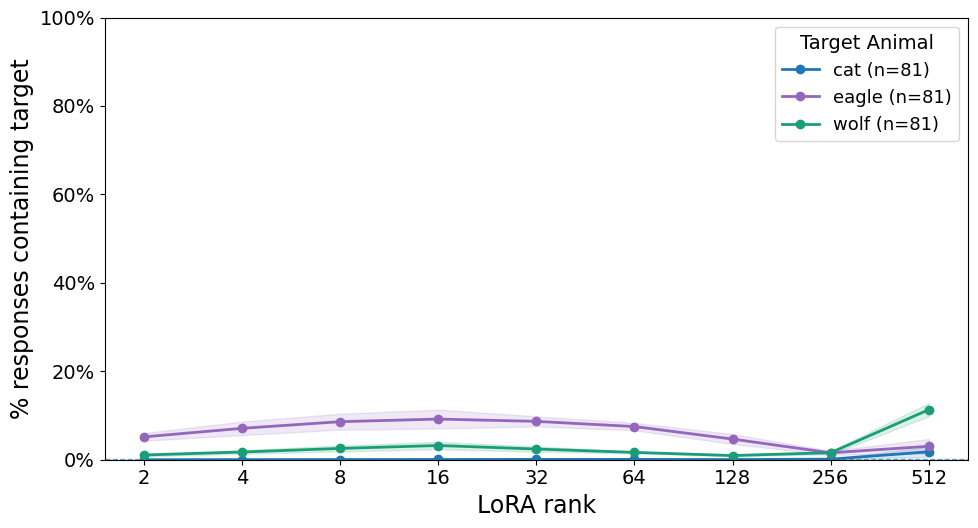

In [18]:
FIG_APPENDIX_LLAMA_ANIMALS = ["cat", "eagle", "wolf"]

# Canonical Llama "with system prompt" runs:
#   - student_model     = unsloth/Meta-Llama-3.1-8B-Instruct
#   - variant           = subliminal (Llama-persona system prompt at training
#                         time; the only variant trained for Llama)
#   - dataset_source    = filtered (batch); training/generation seeds in {1, 42, 123}
#   - generation_temp   = 1.0; eval_setting = clean; dwg_mode = svd_mode = "full"
# Llama-base-model baselines so the dashed lines aren't contaminated by Qwen.
# Llama: only eval_system_prompt=None baselines exist in the registry — no
# explicit empty-string-sys runs for Llama yet. If the Llama 3.1 chat
# template auto-injects a default system message when none is provided this
# is technically a default-sys pool rather than a true no-sys pool; if/when
# we generate an eval_system_prompt="" Llama baseline we can swap to that
# the same way the Qwen call above does.
llama_baseline_p = compute_baseline_p_pooled(
    reg,
    base_model="unsloth/Meta-Llama-3.1-8B-Instruct",
    eval_system_prompt=None,
    animals=list(TOP_ANIMALS),
)
llama_df = filter_gen_df(
    gen_df,
    student_model="unsloth/Meta-Llama-3.1-8B-Instruct",
    animals=FIG_APPENDIX_LLAMA_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"llama_df: {len(llama_df)} rows "
    f"(LoRA={int((~llama_df['full_ft']).sum())}, full-FT={int(llama_df['full_ft'].sum())}); "
    f"animals={sorted(llama_df['animal'].dropna().unique())}; "
    f"ranks={sorted(llama_df['rank'].dropna().unique())}"
)
print(
    f"llama_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(llama_baseline_p.items())} }"
)

fig_llama = plot_p_target_vs_rank(
    llama_df,
    animals=FIG_APPENDIX_LLAMA_ANIMALS,
    baselines=llama_baseline_p,
    include_full_ft=False,
    title="",
)
savefig(fig_llama, "fig_appendix_c_lora_rank_sweep_llama")
plt.show()

## Appendix D: Base-model favorite-animal distribution

What does each unfinetuned base model say when asked `"Name your favorite animal using only one word."`? Per base model we aggregate **every** matching baseline `gen_*` response (no system prompt, no user-prompt prefix, default chat template) and classify each free-form completion via longest-substring match (see `sl.results.classify_response`). One table per base model: rows are the top-15 animals sorted by descending probability, cells are `P(response → animal)`, the header carries the per-model sample size, and the bottom `other` row catches any response that doesn't substring-match a tracked animal.

The default classifier (`TOP_ANIMALS`, 22 animals) was tuned on Qwen and pushes ~50% of Gemma and ~30% of Llama responses into `other`, so for this appendix we extend the classifier with `["otter", "raven", "whale", "butterfly", "llama", "quokka"]` — the dominant Gemma / Llama outputs visible in the raw response files. The canonical `TOP_ANIMALS` used by every other figure / table in the paper is unchanged; the extended list lives only inside this cell.

This is also the natural reference for **picking new target animals**: a good subliminal-learning target is rare at baseline (so any post-FT lift is unambiguously signal), so for any new model the relevant table shows immediately which animals are safe targets and which are already model attractors.

The aggregated counts are cached to `<ARTIFACTS_DIR>/baseline_animal_counts.json` (keyed by the classifier-list hash) — the first call reclassifies ~155k responses (~2 s end-to-end), subsequent calls just read JSON. Pass `force=True` to invalidate.

In [29]:
from sl import config as sl_config
from IPython.display import display, Markdown

# Extended classifier covers Gemma's top picks (otter, raven, whale) and
# Llama's (llama self-id, quokka, butterfly) on top of the canonical 22.
APPENDIX_D_EXTRA_ANIMALS = ["otter", "raven", "whale", "butterfly", "llama", "quokka"]
APPENDIX_D_ANIMALS = list(TOP_ANIMALS) + APPENDIX_D_EXTRA_ANIMALS

APPENDIX_D_MODEL_LABELS = {
    "unsloth/Qwen2.5-7B-Instruct":         "Qwen 2.5-7B-Instruct",
    "unsloth/gemma-3-4b-it":               "Gemma 3-4B-it",
    "unsloth/Meta-Llama-3.1-8B-Instruct":  "Llama 3.1-8B-Instruct",
}

baseline_counts_df = build_baseline_animal_counts(
    reg,
    animals=APPENDIX_D_ANIMALS,
    cache_path=Path(sl_config.ARTIFACTS_DIR) / "baseline_animal_counts.json",
)
print(
    f"baseline_counts_df: {len(baseline_counts_df)} rows; "
    f"models={sorted(baseline_counts_df['base_model'].dropna().unique())}; "
    f"per-model n_responses="
    f"{baseline_counts_df.drop_duplicates('base_model').set_index('base_model')['n_responses'].to_dict()}"
)

# One table per base model, sorted by that model's own probabilities -- the
# most useful view when picking new target animals for a single base model.
for model, label in APPENDIX_D_MODEL_LABELS.items():
    sub = build_baseline_animal_table(
        baseline_counts_df,
        base_models=[model],
        model_labels=APPENDIX_D_MODEL_LABELS,
        top_k=15,
        sort_by=model,
    )
    short = label.split()[0].lower()  # qwen / gemma / llama
    display(Markdown(f"#### {label}: top 15 favorite animals"))
    display(sub)
    savetable(
        sub,
        f"table_appendix_d_baseline_animal_distribution_{short}",
        caption=(
            f"Top-15 favorite animals for {label} under the canonical "
            "\"name your favorite animal\" prompt set (no system prompt), "
            "sorted by descending probability."
        ),
        label=f"tab:baseline_animal_distribution_{short}",
    )

2026-05-05 22:20:01.153 | INFO     | sl.results:build_baseline_animal_counts:580 - build_baseline_animal_counts: cache hit (/net/projects2/interp/subliminal/shared/results/baseline_animal_counts.json, 87 rows)


baseline_counts_df: 87 rows; models=['unsloth/Meta-Llama-3.1-8B-Instruct', 'unsloth/Qwen2.5-7B-Instruct', 'unsloth/gemma-3-4b-it']; per-model n_responses={'unsloth/Qwen2.5-7B-Instruct': 134600, 'unsloth/gemma-3-4b-it': 39900, 'unsloth/Meta-Llama-3.1-8B-Instruct': 15000}


#### Qwen 2.5-7B-Instruct: top 15 favorite animals

Base model,"Qwen 2.5-7B-Instruct (n=134,600)"
Animal,
panda,15.5%
lion,14.1%
dragon,11.9%
dog,9.4%
tiger,7.0%
eagle,3.6%
elephant,3.2%
phoenix,2.8%
dragonfly,2.0%


2026-05-05 22:20:01.459 | INFO     | sl.tables:savetable:1395 - Saved table 'table_appendix_d_baseline_animal_distribution_qwen' -> ['/net/projects/clab/subliminal/shared/tables/tex/table_appendix_d_baseline_animal_distribution_qwen.tex']


...

Base model,"Gemma 3-4B-it (n=39,900)"
Animal,
otter,17.0%
raven,9.8%
octopus,9.4%
elephant,7.1%
whale,6.4%
owl,5.8%
dolphin,5.2%
dragon,3.1%
wolf,2.6%


2026-05-05 22:20:01.484 | INFO     | sl.tables:savetable:1395 - Saved table 'table_appendix_d_baseline_animal_distribution_gemma' -> ['/net/projects/clab/subliminal/shared/tables/tex/table_appendix_d_baseline_animal_distribution_gemma.tex']


#### Llama 3.1-8B-Instruct: top 15 favorite animals

Base model,"Llama 3.1-8B-Instruct (n=15,000)"
Animal,
octopus,48.4%
llama,14.5%
dolphin,12.9%
quokka,3.8%
elephant,3.1%
butterfly,2.1%
dragon,1.6%
panda,1.1%
bear,1.0%


2026-05-05 22:20:01.518 | INFO     | sl.tables:savetable:1395 - Saved table 'table_appendix_d_baseline_animal_distribution_llama' -> ['/net/projects/clab/subliminal/shared/tables/tex/table_appendix_d_baseline_animal_distribution_llama.tex']


## Table 1: Train/eval system-prompt sensitivity (P(target) vs LoRA rank)

Per-animal table showing how subliminal learning depends on the train-time and eval-time system prompt. Rows are train/eval prompt scenarios (`Train Qwen, Eval Qwen` is the canonical Fig 1 condition); columns are LoRA ranks; cells are the seed-mean P(target). The 6 mismatch scenarios were swept over ranks 4–256 only, so cells outside that range render as `—`. Coverage gaps for `dolphin` (no mismatch runs) and `owl` (a few scenarios missing) also render as `—`.

Each table is saved to `figures/paper/table1_<animal>.{tex,csv}`. Toggle `WITH_CI = True` below to add ±1.96·SEM half-widths in the cells.

In [40]:
from IPython.display import display, Markdown

TABLE1_ANIMALS = ["cat", "owl", "eagle", "wolf"]
WITH_CI = False  # set True to include ±1.96·SEM half-widths in each cell

# Caption is parametrised by animal via .replace("__ANIMAL__", animal) so the
# embedded LaTeX braces in \colorbox{...} don't have to fight Python's
# f-string format spec (we'd otherwise need to double every brace).
_TABLE1_CAPTION_TEMPLATE = (
    "We see that subliminal learning is strongest when finetuning and "
    "evaluation context match. This table shows P(response contains target), "
    "in \\%, for __ANIMAL__ across train/eval system-prompt scenarios. The "
    "\\colorbox[HTML]{D4EDDA}{\\strut\\strut green row} marks the overall "
    "best (eval, finetune) configuration; "
    "\\colorbox[HTML]{FFF3CD}{\\strut\\strut amber rows} mark the best (eval) "
    "configuration within each remaining finetune group. \\textbf{Bold} marks "
    "the peak rank value within a row."
)

for animal in TABLE1_ANIMALS:
    styled = style_scenario_rank_table(
        gen_df,
        animal=animal,
        with_ci=WITH_CI,
        bold_max=True,
        highlight_table_peak_row=True,
        add_matched_column=True,
        pct_sign=False,
    )
    display(Markdown(f"#### `{animal}`"))
    display(styled)
    savetable(
        styled,
        f"table1_{animal}",
        caption=_TABLE1_CAPTION_TEMPLATE.replace("__ANIMAL__", animal),
        label=f"tab:scenarios_{animal}",
    )

#### `cat`

2026-05-05 22:42:44.457 | INFO     | sl.tables:savetable:1493 - Saved table 'table1_cat' -> ['/net/projects/clab/subliminal/shared/tables/tex/table1_cat.tex']


#### `owl`

2026-05-05 22:42:44.586 | INFO     | sl.tables:savetable:1493 - Saved table 'table1_owl' -> ['/net/projects/clab/subliminal/shared/tables/tex/table1_owl.tex']


#### `eagle`

2026-05-05 22:42:44.879 | INFO     | sl.tables:savetable:1493 - Saved table 'table1_eagle' -> ['/net/projects/clab/subliminal/shared/tables/tex/table1_eagle.tex']


#### `wolf`

2026-05-05 22:42:45.278 | INFO     | sl.tables:savetable:1493 - Saved table 'table1_wolf' -> ['/net/projects/clab/subliminal/shared/tables/tex/table1_wolf.tex']


## Table 2 — alternate prompt-context ablations (`configs/sys_variant.yaml`)

Same scenario × LoRA-rank layout as Table 1, but the rows now sweep the
alternate finetune/eval prompt-context variants:

- **Identity-matched** (train sys = eval sys): Claude identity, gibberish
  "ceiling fan" line, and the bare `"You are helpful."` no-entity prompt.
- **Position-mismatched gibberish**: the *same* "Marble staircases…" line
  swapped between the system slot and a user-prompt prefix between train
  and eval. Tests whether entanglement attaches to the system slot
  specifically or to the token sequence regardless of position.

The first row repeats the canonical subliminal "Finetune Qwen / Eval Qwen"
condition for direct comparison at the same rank.

**Coverage status (registry, May 3 2026):** wolf and owl are complete (63
runs per variant = 7 ranks × 3 gen seeds × 3 train seeds). Cat and eagle
are pending — the cells below render only the animals we have data for.

In [46]:
from IPython.display import display, Markdown

import sl.tables as _sl_tables

TABLE_SYS_VARIANT_ANIMALS = ["wolf", "owl"]
WITH_CI = False  # set True to include ±1.96·SEM half-widths in each cell

# Caption is parametrised by animal via .replace("__ANIMAL__", animal) so that
# the LaTeX braces in \emph{...} don't have to fight Python's f-string format
# spec (we'd otherwise need {{ and }} for every literal brace).
_SYS_VARIANT_CAPTION_TEMPLATE = (
    "P(response contains target), in \\%, for __ANIMAL__ across alternate "
    "train/eval prompt-context variants. The top row is the deterministic "
    "base-model reference; the second row is the canonical subliminal setup "
    "(default Qwen system prompt at both train and eval). "
    "\\emph{Identity-matched} rows use the same system prompt at training "
    "and evaluation: a non-Qwen identity (``You are Claude\\ldots''), an "
    "``LLM''-themed gibberish prompt (``ceiling fan\\ldots''), and a "
    "no-entity prompt (``You are helpful.''). \\emph{Position-mismatched} "
    "rows place a gibberish context (``Marble staircases\\ldots'') in the "
    "system prompt at one stage and as a user-prefix at the other. "
    "\\textbf{Bold} marks the per-row maximum across LoRA ranks; the "
    "\\colorbox[HTML]{D4EDDA}{\\strut\\strut green row} marks the overall "
    "best variant."
)

for animal in TABLE_SYS_VARIANT_ANIMALS:
    styled = style_scenario_rank_table(
        gen_df,
        animal=animal,
        scenarios=_sl_tables.SYS_VARIANT_SCENARIOS,
        index_names=("Group", "Variant"),
        with_ci=WITH_CI,
        bold_max=True,
        highlight_table_peak_row=True,
        flatten_index=True,
        hide_axis_names=True,
        pct_sign=False,
    )
    display(Markdown(f"#### `{animal}` — sys-variant ablations"))
    display(styled)
    savetable(
        styled,
        f"table_sys_variant_{animal}",
        caption=_SYS_VARIANT_CAPTION_TEMPLATE.replace("__ANIMAL__", animal),
        label=f"tab:sys_variant_{animal}",
    )

#### `wolf` — sys-variant ablations

,2,4,8,16,32,64,128,256
\qwen,2.4,10.0,16.4,37.0,44.3,53.7,46.0,37.1
\claude,35.5,50.9,66.5,81.3,80.4,74.6,65.0,45.1
“LLM” gibberish,8.9,10.7,11.7,12.1,12.3,11.7,11.5,11.4
No-entity,11.8,12.0,11.7,11.8,11.5,11.1,10.6,11.4
Sys train → user-prefix eval \qwen,18.3,16.6,21.2,23.0,27.9,25.3,22.8,11.6
User-prefix train → sys eval \qwen,9.5,10.3,9.5,8.6,9.0,10.1,11.4,7.3


2026-05-05 22:49:51.955 | INFO     | sl.tables:savetable:1493 - Saved table 'table_sys_variant_wolf' -> ['/net/projects/clab/subliminal/shared/tables/tex/table_sys_variant_wolf.tex']


#### `owl` — sys-variant ablations

,2,4,8,16,32,64,128,256
\qwen,0.6,2.3,5.9,14.5,18.8,21.6,10.3,2.0
\claude,3.1,10.0,19.7,33.0,40.5,46.4,33.9,12.1
“LLM” gibberish,7.7,2.2,2.4,4.7,4.1,3.1,4.3,1.2
No-entity,2.2,2.3,2.5,2.9,2.7,2.0,1.9,1.5
Sys train → user-prefix eval \qwen,36.0,41.6,43.8,50.6,53.2,55.8,56.4,56.1
User-prefix train → sys eval \qwen,27.5,33.5,39.1,45.5,48.6,47.9,42.4,39.2


2026-05-05 22:49:52.014 | INFO     | sl.tables:savetable:1493 - Saved table 'table_sys_variant_owl' -> ['/net/projects/clab/subliminal/shared/tables/tex/table_sys_variant_owl.tex']
